# **LIBRARY**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
import json
from datetime import datetime

warnings.filterwarnings("ignore")

# ── Folder Output ────────────────────────────────────────────────────────────
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Fungsi pembantu untuk menyimpan gambar
def save_fig(name: str):
    """Simpan figure matplotlib ke folder output."""
    path = os.path.join(OUTPUT_DIR, f"{name}.png")
    plt.savefig(path, bbox_inches="tight")
    plt.close()
    print(f"  [✓] Grafik disimpan: {path}")

# **MODUL 1 IDENTIFIKASI KEBUTUHAN PENGELOLAAN DATA UNTUK PROSES BISNIS**

In [ ]:
# a Lima pertanyaan analitik yang terukur berdasarkan latar belakang studi kasus.
business_questions = {
    "Q1": "Apakah penggunaan AI generatif (Weekly_GenAI_Hours) berkorelasi positif "
          "atau negatif dengan perubahan GPA mahasiswa (Pre vs Post_Semester_GPA)?",
    "Q2": "Apakah mahasiswa dengan Perceived_AI_Dependency tinggi memiliki "
          "Skill_Retention_Score yang lebih rendah?",
    "Q3": "Bagaimana Institutional_Policy (Banned/Allowed_With_Citation/Encouraged) "
          "memengaruhi rata-rata GPA dan distribusi Burnout_Risk_Level?",
    "Q4": "Mahasiswa dengan profil seperti apa (Major_Category, Year_of_Study, "
          "Perceived_AI_Dependency) yang paling berisiko High Burnout?",
    "Q5": "Apakah segmen Heavy User (>15 jam/minggu) memiliki Traditional_Study_Hours "
          "lebih rendah, dan bagaimana dampaknya pada Post_Semester_GPA?",
    "Q6": "Apakah Prompt_Engineering_Skill memoderasi hubungan antara intensitas "
          "penggunaan AI dan retensi pengetahuan?",
}

print("\n[1a] PERTANYAAN BISNIS ANALITIK:")
for key, val in business_questions.items():
    print(f"  {key}: {val}")

# b. Pemangku Kepentingan (Stakeholders)
stakeholders = {
    "Konsultan Pendidikan": "Merumuskan kebijakan penggunaan AI yang berbasis data",
    "Manajemen Perguruan Tinggi": "Memutuskan Institutional_Policy dan alokasi sumber daya",
    "Dosen / Akademisi": "Memahami dampak AI pada performa belajar mahasiswa per mata kuliah",
    "Tim Kesehatan Mahasiswa": "Mengidentifikasi mahasiswa berisiko burnout untuk intervensi dini",
    "Mahasiswa": "Memahami pola penggunaan AI yang optimal untuk performa akademik",
}

print("\n[1b] PEMANGKU KEPENTINGAN:")
for stakeholder, kepentingan in stakeholders.items():
    print(f"  • {stakeholder}: {kepentingan}")

# c. Matriks Kebutuhan Data
data_requirement_matrix = [
    {"Pertanyaan": "Q1", "Variabel Utama": "Weekly_GenAI_Hours, Pre/Post_Semester_GPA",
     "Analisis": "Korelasi Pearson, scatter plot", "Sumber": "CSV Dataset"},
    {"Pertanyaan": "Q2", "Variabel Utama": "Perceived_AI_Dependency, Skill_Retention_Score",
     "Analisis": "Korelasi, regresi linier", "Sumber": "CSV Dataset"},
    {"Pertanyaan": "Q3", "Variabel Utama": "Institutional_Policy, GPA, Burnout_Risk_Level",
     "Analisis": "GroupBy, ANOVA, distribusi", "Sumber": "CSV Dataset"},
    {"Pertanyaan": "Q4", "Variabel Utama": "Major_Category, Year_of_Study, AI_Dependency, Burnout",
     "Analisis": "Segmentasi, heatmap profil risiko", "Sumber": "CSV Dataset"},
    {"Pertanyaan": "Q5", "Variabel Utama": "Weekly_GenAI_Hours (segmen), Traditional_Study_Hours, GPA",
     "Analisis": "Segmentasi user, boxplot, mean comparison", "Sumber": "CSV Dataset"},
    {"Pertanyaan": "Q6", "Variabel Utama": "Prompt_Engineering_Skill, GenAI_Hours, Skill_Retention_Score",
     "Analisis": "Interaksi variabel, subgroup analysis", "Sumber": "CSV Dataset"},
]

drm_df = pd.DataFrame(data_requirement_matrix)
print("\n[1c] DATA REQUIREMENT MATRIX:")
print(drm_df.to_string(index=False))
drm_df.to_csv(os.path.join(OUTPUT_DIR, "data_requirement_matrix.csv"), index=False)

# d. Format Output Analisis
print("\n[1d] FORMAT OUTPUT ANALISIS:")
print("  • Python Script (.py) — kode lengkap dengan anotasi")
print("  • Clean Dataset (.csv) — data bersih siap analisis lanjutan")
print("  • Grafik EDA (.png)   — minimal 6 visualisasi")
print("  • Data Dictionary (.csv)")
print("  • Laporan narasi (dapat diekspor ke .docx / .pdf)")

# e. Batasan & Asumsi Analisis
print("\n[1e] BATASAN DAN ASUMSI:")
limitations = [
    "Data bersifat cross-sectional (1 semester), bukan longitudinal — tidak dapat menyimpulkan kausalitas.",
    "Dataset bersumber dari survei; potensi response bias dan social desirability bias.",
    "Definisi 'penggunaan AI' mengacu pada jam per minggu yang dilaporkan sendiri (self-reported).",
    "GPA menggunakan skala 4.0; nilai di luar rentang 0–4 dianggap anomali dan akan dibersihkan.",
    "Analisis mencakup level individu mahasiswa, diagregasi per Major_Category, Year_of_Study, Policy.",
    "Tidak tersedia data historis (sebelum era AI) untuk perbandingan baseline jangka panjang.",
]
for lim in limitations:
    print(f"  - {lim}")



[1a] PERTANYAAN BISNIS ANALITIK:
  Q1: Apakah penggunaan AI generatif (Weekly_GenAI_Hours) berkorelasi positif atau negatif dengan perubahan GPA mahasiswa (Pre vs Post_Semester_GPA)?
  Q2: Apakah mahasiswa dengan Perceived_AI_Dependency tinggi memiliki Skill_Retention_Score yang lebih rendah?
  Q3: Bagaimana Institutional_Policy (Banned/Allowed_With_Citation/Encouraged) memengaruhi rata-rata GPA dan distribusi Burnout_Risk_Level?
  Q4: Mahasiswa dengan profil seperti apa (Major_Category, Year_of_Study, Perceived_AI_Dependency) yang paling berisiko High Burnout?
  Q5: Apakah segmen Heavy User (>15 jam/minggu) memiliki Traditional_Study_Hours lebih rendah, dan bagaimana dampaknya pada Post_Semester_GPA?
  Q6: Apakah Prompt_Engineering_Skill memoderasi hubungan antara intensitas penggunaan AI dan retensi pengetahuan?

[1b] PEMANGKU KEPENTINGAN:
  • Konsultan Pendidikan: Merumuskan kebijakan penggunaan AI yang berbasis data
  • Manajemen Perguruan Tinggi: Memutuskan Institutional_Policy d

In [ ]:
# Pengaturan Global Visualisasi
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

# **MODUL 2 MENGUMPULKAN DATA**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install xlrd

## a. Muat dataset & dokumentasi sumber

In [ ]:
# a. Muat dataset & dokumentasi sumber
# Membaca file CSV dengan encoding UTF-8
DATA_PATH = '/content/drive/MyDrive/data bnsp/ai_student_impact_dataset (1).csv'
df_raw = pd.read_csv(DATA_PATH)

print(f"\n[2a] SUMBER DATA:")
print(f"  File          : {DATA_PATH}")
print(f"  Sumber Data   : Survei mahasiswa + Sistem Informasi Akademik")
print(f"  Periode       : Satu semester penuh")
print(f"  Cakupan       : Berbagai perguruan tinggi internasional")
print(f"  Jumlah baris  : {len(df_raw):,} records")
print(f"  Jumlah kolom  : {df_raw.shape[1]} variabel")
print(f"  Format        : CSV (Comma-Separated Values)")
print(f"  Ukuran memori : {df_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\n  Nama kolom:")
for i, col in enumerate(df_raw.columns, start=1):
    print(f"    {i}. {col}")


[2a] SUMBER DATA:
  File          : /content/drive/MyDrive/data bnsp/ai_student_impact_dataset (1).csv
  Sumber Data   : Survei mahasiswa + Sistem Informasi Akademik
  Periode       : Satu semester penuh
  Cakupan       : Berbagai perguruan tinggi internasional
  Jumlah baris  : 50,000 records
  Jumlah kolom  : 16 variabel
  Format        : CSV (Comma-Separated Values)
  Ukuran memori : 24.51 MB

  Nama kolom:
    1. Student_ID
    2. Major_Category
    3. Year_of_Study
    4. Pre_Semester_GPA
    5. Weekly_GenAI_Hours
    6. Primary_Use_Case
    7. Prompt_Engineering_Skill
    8. Tool_Diversity
    9. Paid_Subscription
    10. Traditional_Study_Hours
    11. Perceived_AI_Dependency
    12. Institutional_Policy
    13. Anxiety_Level_During_Exams
    14. Post_Semester_GPA
    15. Skill_Retention_Score
    16. Burnout_Risk_Level


## b. Kamus Data (Data Dictionary)

In [ ]:
import re

def clean_range_category(text):
    # Remove text in parentheses (e.g., "(deskripsi)", "(skala Likert)", "(terdapat anomali '123')")
    text = re.sub(r'\s*\(.*\)', '', text)
    # Remove ", anomali: " and anything after it
    text = re.sub(r',\s*anomali:.*', '', text)
    return text.strip()

# b. Kamus Data (Data Dictionary)
# Mendefinisikan metadata setiap variabel secara manual berdasarkan domain knowledge
data_dictionary = [
    {
        "Kolom": "Student_ID",
        "Tipe Data": "object (seharusnya int)",
        "Rentang/Kategori": "6-digit angka unik",
        "Definisi Bisnis": "Identifikasi unik setiap mahasiswa dalam dataset"
    },
    {
        "Kolom": "Major_Category",
        "Tipe Data": "object (kategorikal)",
        "Rentang/Kategori": "Business, Engineering, Humanities, Medical, Science, Social Science",
        "Definisi Bisnis": "Rumpun bidang studi mahasiswa"
    },
    {
        "Kolom": "Year_of_Study",
        "Tipe Data": "object (kategorikal ordinal)",
        "Rentang/Kategori": "Freshman, Sophomore, Junior, Senior (terdapat anomali '123')",
        "Definisi Bisnis": "Jenjang tahun studi mahasiswa"
    },
    {
        "Kolom": "Pre_Semester_GPA",
        "Tipe Data": "float64",
        "Rentang/Kategori": "0.0 – 4.0",
        "Definisi Bisnis": "IPK mahasiswa sebelum semester yang diamati"
    },
    {
        "Kolom": "Weekly_GenAI_Hours",
        "Tipe Data": "float64",
        "Rentang/Kategori": "0 – ~40 jam/minggu",
        "Definisi Bisnis": "Rata-rata jam per minggu mahasiswa menggunakan AI generatif"
    },
    {
        "Kolom": "Primary_Use_Case",
        "Tipe Data": "object (kategorikal)",
        "Rentang/Kategori": "Coding_Assistance, Copywriting/Drafting, Ideation, "
                            "Problem_Solving, Research_Assistance, Summarizing_Reading",
        "Definisi Bisnis": "Tujuan utama penggunaan AI generatif mahasiswa"
    },
    {
        "Kolom": "Prompt_Engineering_Skill",
        "Tipe Data": "object (kategorikal ordinal)",
        "Rentang/Kategori": "Beginner, Intermediate, Advanced",
        "Definisi Bisnis": "Tingkat kemampuan mahasiswa dalam merumuskan prompt AI"
    },
    {
        "Kolom": "Tool_Diversity",
        "Tipe Data": "int64",
        "Rentang/Kategori": "1 – 5 (deskripsi), anomali: hingga 18",
        "Definisi Bisnis": "Jumlah jenis alat AI berbeda yang digunakan"
    },
    {
        "Kolom": "Paid_Subscription",
        "Tipe Data": "object (boolean mixed)",
        "Rentang/Kategori": "True / False",
        "Definisi Bisnis": "Apakah mahasiswa berlangganan layanan AI berbayar"
    },
    {
        "Kolom": "Traditional_Study_Hours",
        "Tipe Data": "float64",
        "Rentang/Kategori": "0 – ~30 jam/minggu",
        "Definisi Bisnis": "Rata-rata jam belajar konvensional (tanpa AI) per minggu"
    },
    {
        "Kolom": "Perceived_AI_Dependency",
        "Tipe Data": "int64",
        "Rentang/Kategori": "1 – 5 (skala Likert)",
        "Definisi Bisnis": "Persepsi ketergantungan mahasiswa terhadap AI (1=rendah, 5=sangat tinggi)"
    },
    {
        "Kolom": "Institutional_Policy",
        "Tipe Data": "object (kategorikal)",
        "Rentang/Kategori": "Allowed_With_Citation, Actively_Encouraged, Strict_Ban",
        "Definisi Bisnis": "Kebijakan institusi perguruan tinggi mengenai penggunaan AI"
    },
    {
        "Kolom": "Anxiety_Level_During_Exams",
        "Tipe Data": "int64",
        "Rentang/Kategori": "1 – 10",
        "Definisi Bisnis": "Tingkat kecemasan mahasiswa saat ujian (1=sangat rendah, 10=sangat tinggi)"
    },
    {
        "Kolom": "Post_Semester_GPA",
        "Tipe Data": "float64",
        "Rentang/Kategori": "0.0 – 4.0 (anomali: hingga 10.39)",
        "Definisi Bisnis": "IPK mahasiswa setelah semester yang diamati"
    },
    {
        "Kolom": "Skill_Retention_Score",
        "Tipe Data": "float64",
        "Rentang/Kategori": "0 – 100",
        "Definisi Bisnis": "Skor retensi pengetahuan/keterampilan mahasiswa (tes pasca-semester)"
    },
    {
        "Kolom": "Burnout_Risk_Level",
        "Tipe Data": "object (kategorikal ordinal)",
        "Rentang/Kategori": "Low, Medium, High",
        "Definisi Bisnis": "Tingkat risiko burnout akademik mahasiswa"
    },
]

# Apply the cleaning function to the 'Rentang/Kategori' field of each item
for item in data_dictionary:
    if "Rentang/Kategori" in item:
        item["Rentang/Kategori"] = clean_range_category(item["Rentang/Kategori"])

dd_df = pd.DataFrame(data_dictionary)
dd_path = os.path.join(OUTPUT_DIR, "data_dictionary.csv")
dd_df.to_csv(dd_path, index=False)
print(f"\n[2b] KAMUS DATA — {len(data_dictionary)} variabel:")
print(dd_df[["Kolom", "Tipe Data", "Definisi Bisnis"]].to_string(index=False))
print(f"  [✓] Disimpan: {dd_path}")


[2b] KAMUS DATA — 16 variabel:
                     Kolom                    Tipe Data                                                            Definisi Bisnis
                Student_ID      object (seharusnya int)                           Identifikasi unik setiap mahasiswa dalam dataset
            Major_Category         object (kategorikal)                                              Rumpun bidang studi mahasiswa
             Year_of_Study object (kategorikal ordinal)                                              Jenjang tahun studi mahasiswa
          Pre_Semester_GPA                      float64                                IPK mahasiswa sebelum semester yang diamati
        Weekly_GenAI_Hours                      float64                Rata-rata jam per minggu mahasiswa menggunakan AI generatif
          Primary_Use_Case         object (kategorikal)                             Tujuan utama penggunaan AI generatif mahasiswa
  Prompt_Engineering_Skill object (kategorikal ordi

## c. Profiling Data Awal

In [ ]:
# c. Profiling Data Awal
print("\n[2c] PROFILING DATA AWAL:")

# Jumlah baris dan kolom
n_baris, n_kolom = df_raw.shape

print(f"  Jumlah baris : {n_baris:,}")
print(f"  Jumlah kolom : {n_kolom}")

# Jumlah missing values per kolom
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)

# Jumlah kolom yang memiliki missing value
n_col_missing = (missing > 0).sum()

# Total baris yang terdampak missing value minimal pada satu kolom
n_row_missing = df_raw.isnull().any(axis=1).sum()
n_row_missing_pct = (n_row_missing / len(df_raw) * 100).round(2)

profile = pd.DataFrame({
    "Kolom": df_raw.columns,
    "Tipe Data": df_raw.dtypes.values,
    "Missing Values": missing.values,
    "Missing (%)": missing_pct.values,
    "Unik": [df_raw[c].nunique() for c in df_raw.columns],
})

print(profile.to_string(index=False))

print(f"\n  Jumlah kolom dengan missing value : {n_col_missing}")
print(f"  Total baris terdampak missing     : {n_row_missing} baris ({n_row_missing_pct}%)")

# Jumlah duplikat
n_dup = df_raw.duplicated().sum()
print(f"\n  Jumlah baris duplikat: {n_dup}")
print(f"  Distribusi tipe data: {dict(df_raw.dtypes.value_counts())}")


[2c] PROFILING DATA AWAL:
  Jumlah baris : 50,000
  Jumlah kolom : 16
                     Kolom Tipe Data  Missing Values  Missing (%)  Unik
                Student_ID    object               0          0.0 50000
            Major_Category    object               2          0.0     5
             Year_of_Study    object               2          0.0     6
          Pre_Semester_GPA   float64               2          0.0  2390
        Weekly_GenAI_Hours   float64               2          0.0  3566
          Primary_Use_Case    object               2          0.0     5
  Prompt_Engineering_Skill    object               2          0.0     3
            Tool_Diversity   float64               2          0.0     6
         Paid_Subscription    object               2          0.0     2
   Traditional_Study_Hours   float64               2          0.0  2516
   Perceived_AI_Dependency   float64               2          0.0    10
      Institutional_Policy    object               2          0.0

## d. Proses Pengumpulan Data

In [ ]:
# d. Proses Pengumpulan Data
print("\n[2d] DOKUMENTASI PROSES PENGUMPULAN DATA:")
print("""
  Sumber Data   : Dataset simulasi/riset berbasis survei mahasiswa internasional
  Periode       : Satu semester penuh (± 16 minggu)
  Metode        : Survei online + ekstraksi sistem informasi akademik
  Potensi Bias  :
    - Voluntary response bias: mahasiswa yang aktif mungkin over-represented
    - Self-reporting bias: jam penggunaan AI dan ketergantungan dilaporkan sendiri
    - Survivorship bias: mahasiswa yang DO (dropout) kemungkinan tidak tercakup
    - International diversity: kebijakan institusi dapat bervariasi sangat lebar
""")


[2d] DOKUMENTASI PROSES PENGUMPULAN DATA:

  Sumber Data   : Dataset simulasi/riset berbasis survei mahasiswa internasional
  Periode       : Satu semester penuh (± 16 minggu)
  Metode        : Survei online + ekstraksi sistem informasi akademik
  Potensi Bias  :
    - Voluntary response bias: mahasiswa yang aktif mungkin over-represented
    - Self-reporting bias: jam penggunaan AI dan ketergantungan dilaporkan sendiri
    - Survivorship bias: mahasiswa yang DO (dropout) kemungkinan tidak tercakup
    - International diversity: kebijakan institusi dapat bervariasi sangat lebar



# **MODUL 3  MENELAAH DATA (EXPLORATORY DATA ANALYSIS)**

In [ ]:
# Gunakan salinan data mentah untuk EDA awal (sebelum cleaning)
df = df_raw.copy()

## a. Statistik Deskriptif Variabel Numerik

In [ ]:
# Menghitung mean, median, std, min, max, Q1, Q3 untuk semua kolom numerik
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
desc = df[numeric_cols].describe(percentiles=[0.25, 0.5, 0.75]).T
desc.columns = ["count", "mean", "std", "min", "Q1(25%)", "median(50%)", "Q3(75%)", "max"]
print("\n[3a] STATISTIK DESKRIPTIF VARIABEL NUMERIK:")
print(desc.round(3).to_string())
desc.to_csv(os.path.join(OUTPUT_DIR, "statistik_deskriptif.csv"))


[3a] STATISTIK DESKRIPTIF VARIABEL NUMERIK:
                              count    mean     std     min  Q1(25%)  median(50%)  Q3(75%)      max
Pre_Semester_GPA            49998.0   3.146   0.481   1.183    2.834        3.210    3.521   12.249
Weekly_GenAI_Hours          49998.0   8.428   8.270   0.000    2.390        5.800   11.720   40.000
Tool_Diversity              49998.0   2.801   1.190   1.000    2.000        3.000    4.000   18.000
Traditional_Study_Hours     49998.0  11.209   5.156   1.000    7.560       11.180   14.710   35.860
Perceived_AI_Dependency     49998.0   3.505   1.821   1.000    2.000        3.000    5.000   10.000
Anxiety_Level_During_Exams  49998.0   4.271   2.144   1.000    3.000        4.000    6.000   10.000
Post_Semester_GPA           49998.0   3.349   0.497   1.000    3.024        3.421    3.749   10.389
Skill_Retention_Score       49998.0  75.798  13.282  10.780   66.820       76.000   85.188  100.000


## b. Distribusi Variabel Kategorik

In [ ]:
cat_cols = ["Major_Category", "Year_of_Study", "Burnout_Risk_Level",
            "Institutional_Policy", "Primary_Use_Case"]
print("\n[3b] DISTRIBUSI VARIABEL KATEGORIK:")
for col in cat_cols:
    freq = df[col].value_counts(dropna=False)
    pct  = (freq / len(df) * 100).round(2)
    cat_summary = pd.DataFrame({"Frekuensi": freq, "Persentase(%)": pct})
    print(f"\n  >> {col}:")
    print(cat_summary.to_string())


[3b] DISTRIBUSI VARIABEL KATEGORIK:

  >> Major_Category:
                Frekuensi  Persentase(%)
Major_Category                          
STEM                15059          30.12
Business            12537          25.07
Humanities           9994          19.99
Medical              6475          12.95
Arts                 5933          11.87
NaN                     2           0.00

  >> Year_of_Study:
               Frekuensi  Persentase(%)
Year_of_Study                          
Junior             11043          22.09
Freshman           11030          22.06
Senior             10634          21.27
Sophomore           9860          19.72
Graduate            7430          14.86
NaN                    2           0.00
123                    1           0.00

  >> Burnout_Risk_Level:
                    Frekuensi  Persentase(%)
Burnout_Risk_Level                          
Medium                  21143          42.29
Low                     16369          32.74
High                    12

## c. Visualisasi EDA

In [ ]:
# Palet warna konsisten

# Palet umum
PALETTE_MAIN = {
    "navy": "#264653",
    "teal": "#2A9D8F",
    "green": "#6A994E",
    "yellow": "#E9C46A",
    "orange": "#F4A261",
    "red": "#E76F51",
    "blue": "#457B9D",
    "sky": "#A8DADC",
    "purple": "#7B2CBF",
    "pink": "#D76D77",
    "gray": "#6C757D"
}

# Palet untuk GPA
PALETTE_GPA = {
    "Pre": "#A8DADC",
    "Post": "#457B9D",
    "Delta_Positive": "#2A9D8F",
    "Delta_Negative": "#E76F51"
}

# Palet untuk Burnout Risk Level
PALETTE_BURNOUT = {
    "Low": PALETTE_MAIN["green"],
    "Medium": PALETTE_MAIN["yellow"],
    "High": PALETTE_MAIN["red"]
}

# Palet untuk Institutional Policy
PALETTE_POLICY = {
    "Strict_Ban": PALETTE_MAIN["red"],
    "Allowed_With_Citation": PALETTE_MAIN["blue"],
    "Actively_Encouraged": PALETTE_MAIN["green"]
}

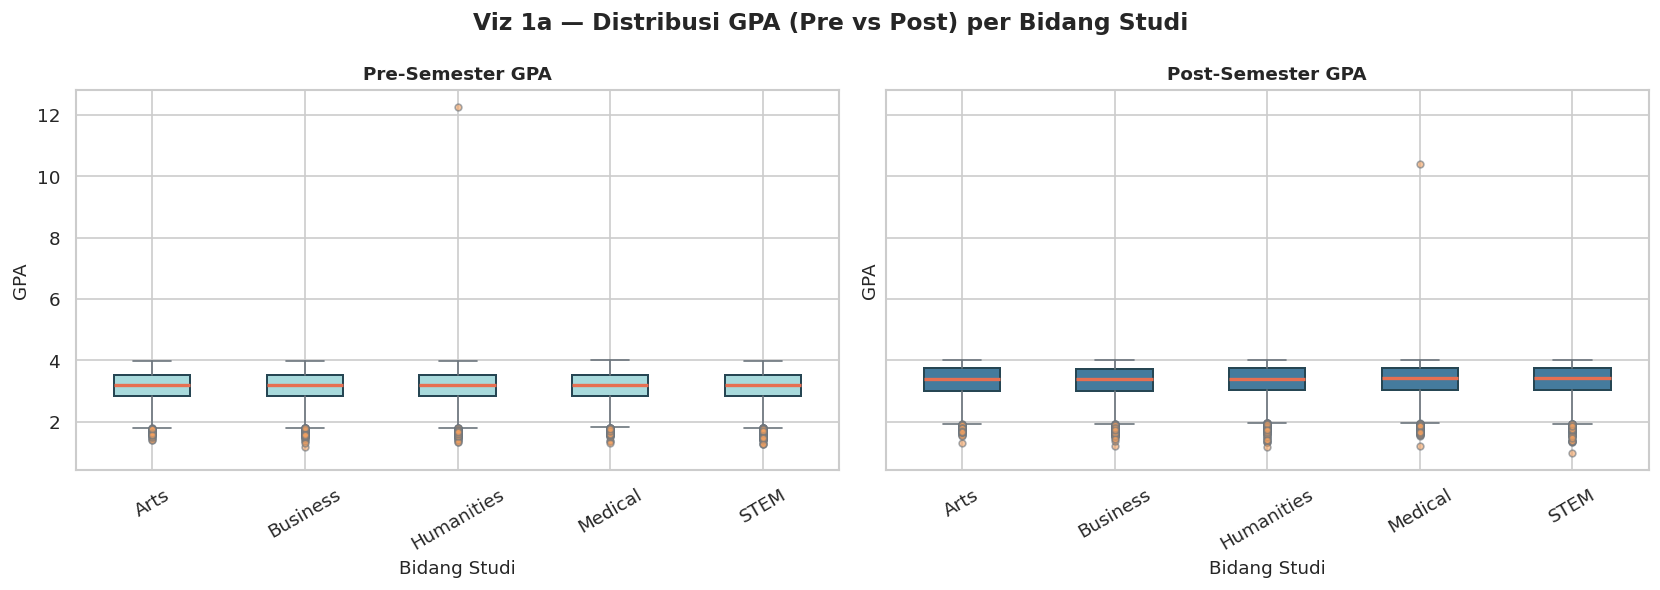

  [✓] Grafik disimpan: output/viz1a_gpa_pre_post_per_major.png


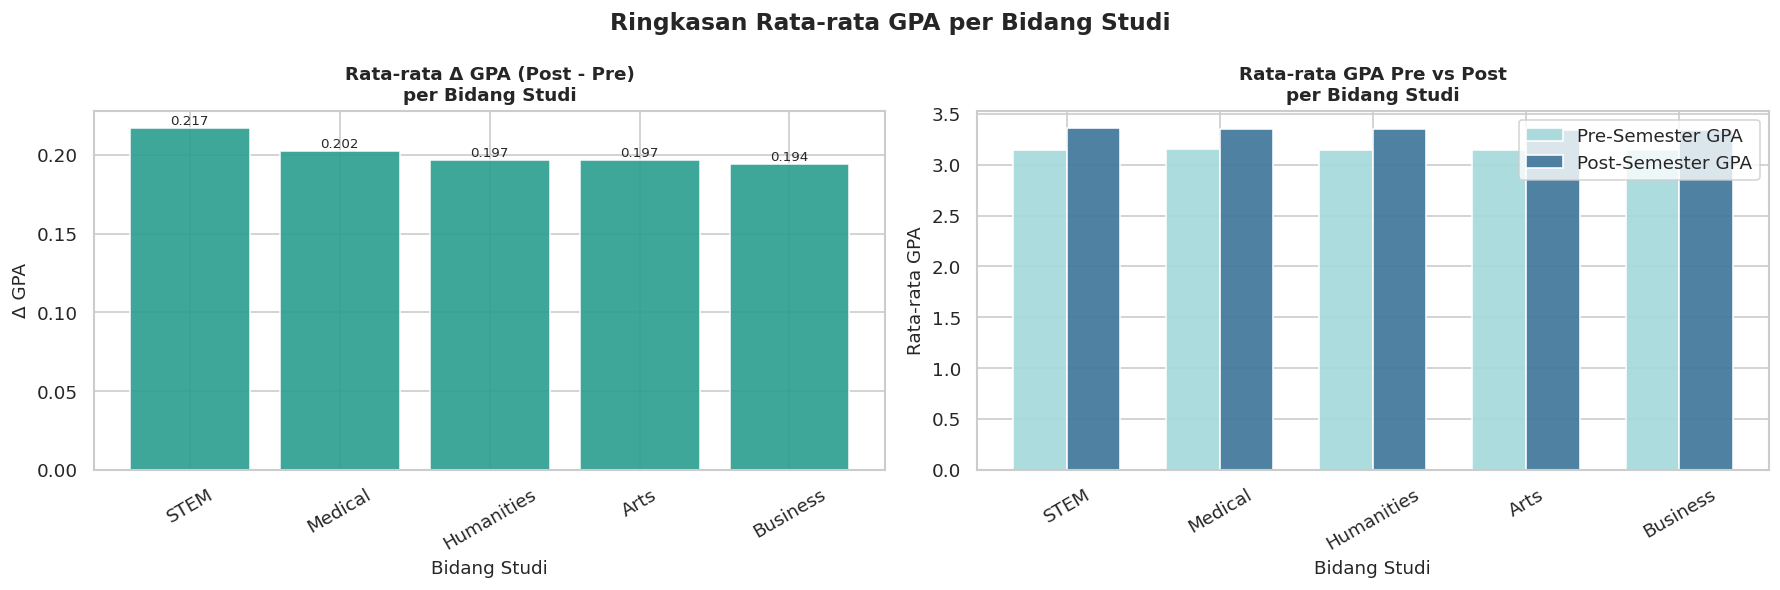

  [✓] Grafik disimpan: output/viz1b_rata_rata_gpa_per_major.png


In [ ]:
# Viz 1a: Distribusi GPA (Pre vs Post) per Major_Category
# Tujuan: melihat apakah terdapat perubahan GPA yang berbeda antar bidang studi

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle(
    "Viz 1a — Distribusi GPA (Pre vs Post) per Bidang Studi",
    fontsize=14,
    fontweight="bold"
)

for ax, col, title, box_color in zip(
    axes,
    ["Pre_Semester_GPA", "Post_Semester_GPA"],
    ["Pre-Semester GPA", "Post-Semester GPA"],
    [PALETTE_GPA["Pre"], PALETTE_GPA["Post"]]
):
    df.boxplot(
        column=col,
        by="Major_Category",
        ax=ax,
        patch_artist=True,
        boxprops=dict(
            facecolor=box_color,
            color=PALETTE_MAIN["navy"],
            linewidth=1.2
        ),
        medianprops=dict(
            color=PALETTE_MAIN["red"],
            linewidth=2
        ),
        whiskerprops=dict(
            color=PALETTE_MAIN["gray"],
            linewidth=1
        ),
        capprops=dict(
            color=PALETTE_MAIN["gray"],
            linewidth=1
        ),
        flierprops=dict(
            marker="o",
            markerfacecolor=PALETTE_MAIN["orange"],
            markeredgecolor=PALETTE_MAIN["gray"],
            markersize=4,
            alpha=0.6
        )
    )

    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Bidang Studi")
    ax.set_ylabel("GPA")
    ax.tick_params(axis="x", rotation=30)

# Hilangkan judul otomatis dari pandas boxplot
plt.suptitle("Viz 1a — Distribusi GPA (Pre vs Post) per Bidang Studi",
             fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()
save_fig("viz1a_gpa_pre_post_per_major")

# Viz 1b: Rata-rata Perubahan GPA dan Perbandingan Pre vs Post
# Tujuan: melihat rata-rata perubahan GPA setelah penggunaan AI per bidang studi

# Hitung rata-rata GPA Pre dan Post per bidang studi
gpa_major = (
    df.groupby("Major_Category")[["Pre_Semester_GPA", "Post_Semester_GPA"]]
    .mean()
    .reset_index()
)

# Hitung perubahan GPA: Post - Pre
gpa_major["Delta_GPA"] = (
    gpa_major["Post_Semester_GPA"] - gpa_major["Pre_Semester_GPA"]
)

# Urutkan berdasarkan perubahan GPA
gpa_major = gpa_major.sort_values("Delta_GPA", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(
    "Ringkasan Rata-rata GPA per Bidang Studi",
    fontsize=14,
    fontweight="bold"
)

# Plot 1: Rata-rata Δ GPA
delta_colors = [
    PALETTE_GPA["Delta_Positive"] if val >= 0 else PALETTE_GPA["Delta_Negative"]
    for val in gpa_major["Delta_GPA"]
]

axes[0].bar(
    gpa_major["Major_Category"],
    gpa_major["Delta_GPA"],
    color=delta_colors,
    alpha=0.9
)

axes[0].axhline(0, color=PALETTE_MAIN["gray"], linewidth=1)
axes[0].set_title(
    "Rata-rata Δ GPA (Post - Pre)\nper Bidang Studi",
    fontsize=11,
    fontweight="bold"
)
axes[0].set_xlabel("Bidang Studi")
axes[0].set_ylabel("Δ GPA")
axes[0].tick_params(axis="x", rotation=30)

# Tambahkan label angka pada batang
for i, val in enumerate(gpa_major["Delta_GPA"]):
    axes[0].text(
        i,
        val,
        f"{val:.3f}",
        ha="center",
        va="bottom" if val >= 0 else "top",
        fontsize=8
    )

# ── Plot 2: Rata-rata GPA Pre vs Post ──
x = np.arange(len(gpa_major["Major_Category"]))
width = 0.35

axes[1].bar(
    x - width / 2,
    gpa_major["Pre_Semester_GPA"],
    width,
    label="Pre-Semester GPA",
    color=PALETTE_GPA["Pre"],
    alpha=0.95
)

axes[1].bar(
    x + width / 2,
    gpa_major["Post_Semester_GPA"],
    width,
    label="Post-Semester GPA",
    color=PALETTE_GPA["Post"],
    alpha=0.95
)

axes[1].set_title(
    "Rata-rata GPA Pre vs Post\nper Bidang Studi",
    fontsize=11,
    fontweight="bold"
)
axes[1].set_xlabel("Bidang Studi")
axes[1].set_ylabel("Rata-rata GPA")
axes[1].set_xticks(x)
axes[1].set_xticklabels(gpa_major["Major_Category"], rotation=30)
axes[1].legend()

plt.tight_layout()
plt.show()
save_fig("viz1b_rata_rata_gpa_per_major")

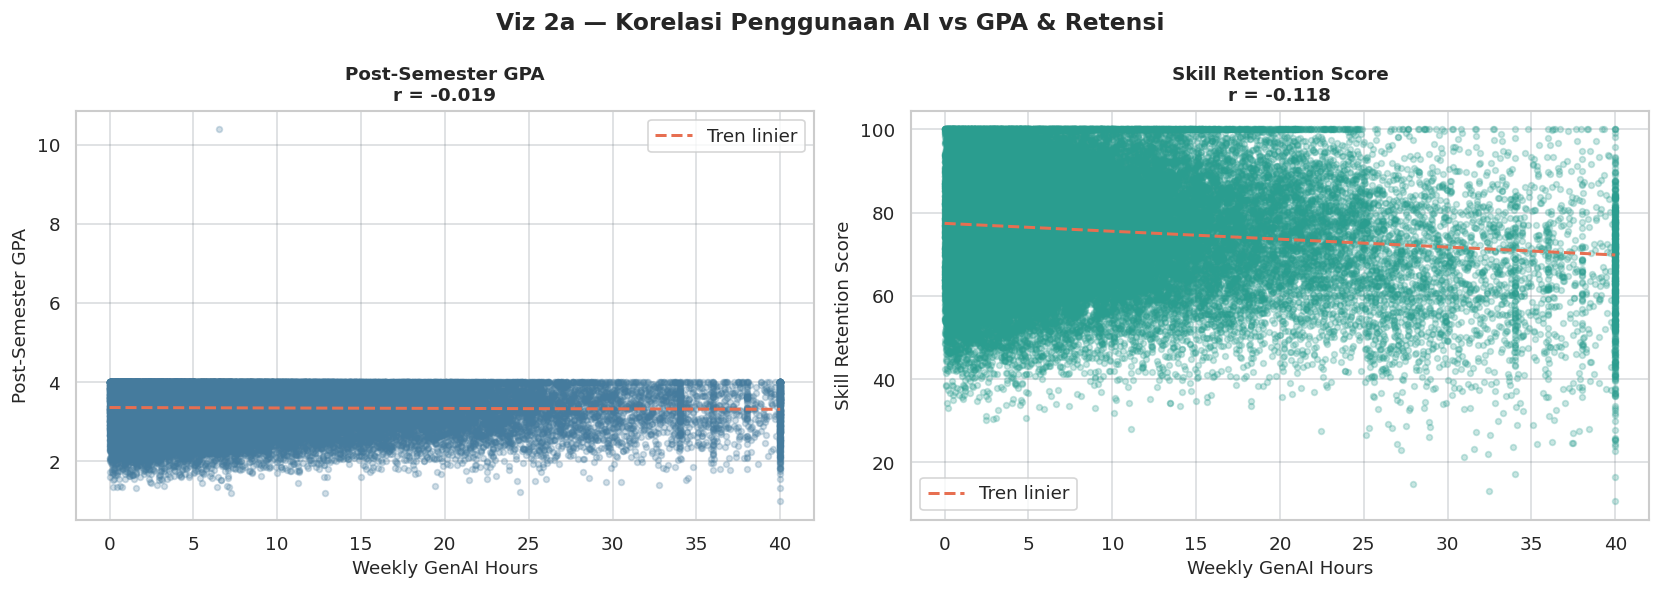

  [✓] Grafik disimpan: output/viz2a_korelasi_genai_hours_vs_gpa_retention.png


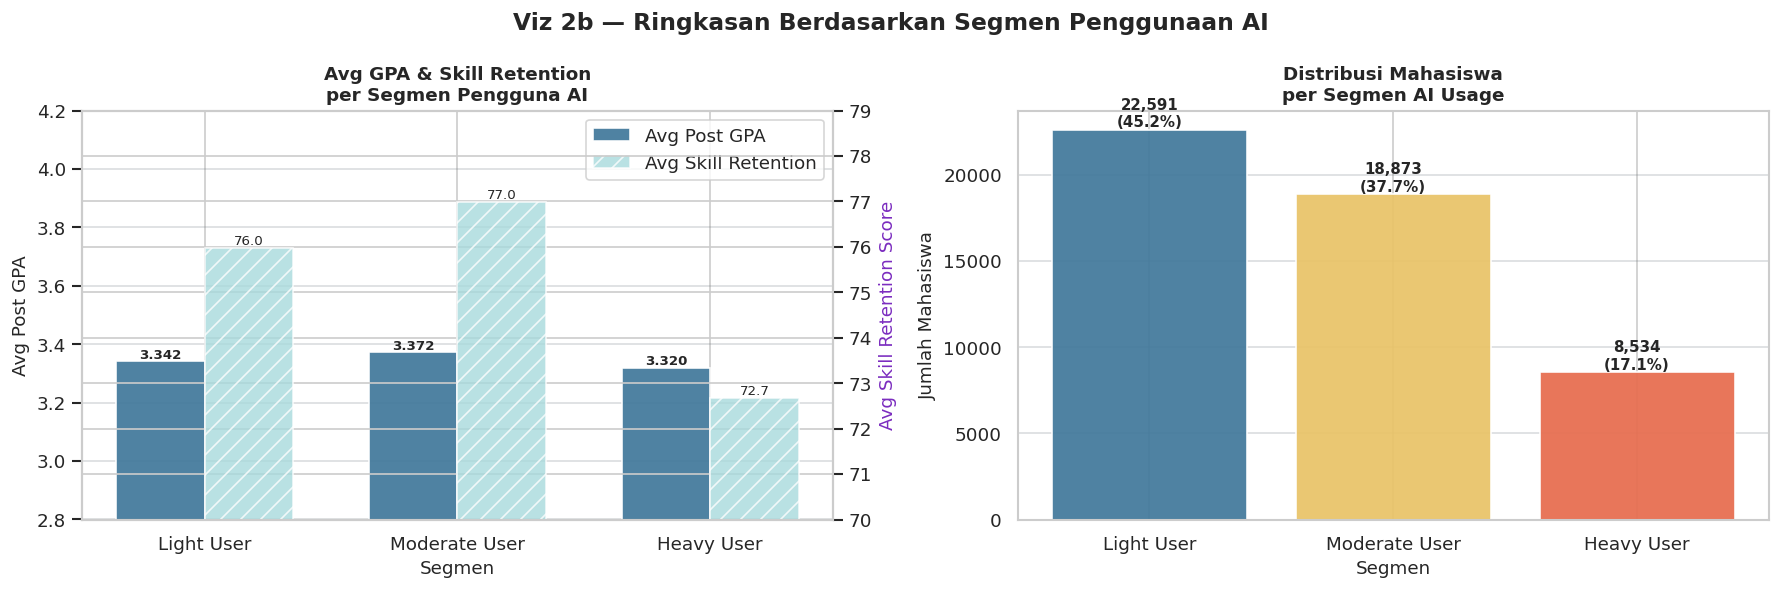

  [✓] Grafik disimpan: output/viz2b_ringkasan_segmen_ai.png


In [ ]:
# Viz 2a: Korelasi Weekly_GenAI_Hours vs Post GPA & Skill Retention
# Tujuan: memahami hubungan antara intensitas penggunaan AI dengan output akademik

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Viz 2a — Korelasi Penggunaan AI vs GPA & Retensi",
    fontsize=14,
    fontweight="bold"
)

for ax, y_col, y_label, point_color in zip(
    axes,
    ["Post_Semester_GPA", "Skill_Retention_Score"],
    ["Post-Semester GPA", "Skill Retention Score"],
    [PALETTE_MAIN["blue"], PALETTE_MAIN["teal"]]
):
    # Drop NA biar x dan y sejajar
    temp = df[["Weekly_GenAI_Hours", y_col]].dropna()

    # Scatter plot
    ax.scatter(
        temp["Weekly_GenAI_Hours"],
        temp[y_col],
        alpha=0.25,
        s=12,
        color=point_color
    )

    # Hitung korelasi Pearson
    corr_val = temp["Weekly_GenAI_Hours"].corr(temp[y_col])

    # Garis tren linier
    z = np.polyfit(temp["Weekly_GenAI_Hours"], temp[y_col], 1)
    p = np.poly1d(z)
    x_line = np.linspace(
        temp["Weekly_GenAI_Hours"].min(),
        temp["Weekly_GenAI_Hours"].max(),
        200
    )
    ax.plot(
        x_line,
        p(x_line),
        linestyle="--",
        linewidth=1.8,
        color=PALETTE_MAIN["red"],
        label="Tren linier"
    )

    ax.set_title(f"{y_label}\nr = {corr_val:.3f}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Weekly GenAI Hours")
    ax.set_ylabel(y_label)
    ax.grid(alpha=0.25, color=PALETTE_MAIN["gray"])
    ax.legend()

plt.tight_layout()
plt.show()
save_fig("viz2a_korelasi_genai_hours_vs_gpa_retention")

# Viz 2b: Ringkasan per Segmen Penggunaan AI
# Tujuan: merangkum performa akademik dan distribusi mahasiswa berdasarkan
# intensitas penggunaan GenAI

# Membuat segmen AI usage menjadi 3 kategori seperti gambar referensi
AI_SEGMENT_ORDER = ["Light User", "Moderate User", "Heavy User"]

df["AI_Usage_Segment"] = pd.cut(
    df["Weekly_GenAI_Hours"],
    bins=[-np.inf, 5, 15, np.inf],
    labels=AI_SEGMENT_ORDER
)

# Warna segmen pakai palette yang sudah ada
segment_colors = [
    PALETTE_MAIN["blue"],    # Light User
    PALETTE_MAIN["yellow"],  # Moderate User
    PALETTE_MAIN["red"]      # Heavy User
]

# Ringkasan rata-rata
seg_summary = (
    df.groupby("AI_Usage_Segment", observed=False)[
        ["Post_Semester_GPA", "Skill_Retention_Score"]
    ]
    .mean()
    .reindex(AI_SEGMENT_ORDER)
)

# Distribusi jumlah mahasiswa
seg_count = (
    df["AI_Usage_Segment"]
    .value_counts()
    .reindex(AI_SEGMENT_ORDER)
)

seg_pct = (seg_count / seg_count.sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(
    "Viz 2b — Ringkasan Berdasarkan Segmen Penggunaan AI",
    fontsize=14,
    fontweight="bold"
)

# Plot kiri: Avg Post GPA dan Avg Skill Retention dengan dua sumbu Y
ax1 = axes[0]
ax2 = ax1.twinx()

x = np.arange(len(AI_SEGMENT_ORDER))
width = 0.35

bars_gpa = ax1.bar(
    x - width/2,
    seg_summary["Post_Semester_GPA"],
    width,
    label="Avg Post GPA",
    color=PALETTE_GPA["Post"],
    alpha=0.95
)

bars_retention = ax2.bar(
    x + width/2,
    seg_summary["Skill_Retention_Score"],
    width,
    label="Avg Skill Retention",
    color=PALETTE_MAIN["sky"],
    alpha=0.80,
    hatch="//"
)

ax1.set_title(
    "Avg GPA & Skill Retention\nper Segmen Pengguna AI",
    fontsize=11,
    fontweight="bold"
)

ax1.set_xlabel("Segmen")
ax1.set_ylabel("Avg Post GPA")
ax2.set_ylabel("Avg Skill Retention Score", color=PALETTE_MAIN["purple"])

ax1.set_xticks(x)
ax1.set_xticklabels(AI_SEGMENT_ORDER)

# Atur skala biar GPA kelihatan jelas
ax1.set_ylim(2.8, 4.2)
ax2.set_ylim(70, 79)

ax1.grid(axis="y", alpha=0.25, color=PALETTE_MAIN["gray"])

# Gabungkan legend dari dua axis
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper right")

# Label angka GPA
for bar in bars_gpa:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold"
    )

# Label angka Skill Retention
for bar in bars_retention:
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.1f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

# Plot kanan: Distribusi Mahasiswa
bars = axes[1].bar(
    AI_SEGMENT_ORDER,
    seg_count.values,
    color=segment_colors,
    alpha=0.95
)

axes[1].set_title(
    "Distribusi Mahasiswa\nper Segmen AI Usage",
    fontsize=11,
    fontweight="bold"
)

axes[1].set_xlabel("Segmen")
axes[1].set_ylabel("Jumlah Mahasiswa")
axes[1].grid(axis="y", alpha=0.25, color=PALETTE_MAIN["gray"])

# Label count + persentase
for bar, count, pct in zip(bars, seg_count.values, seg_pct.values):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{int(count):,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()
save_fig("viz2b_ringkasan_segmen_ai")

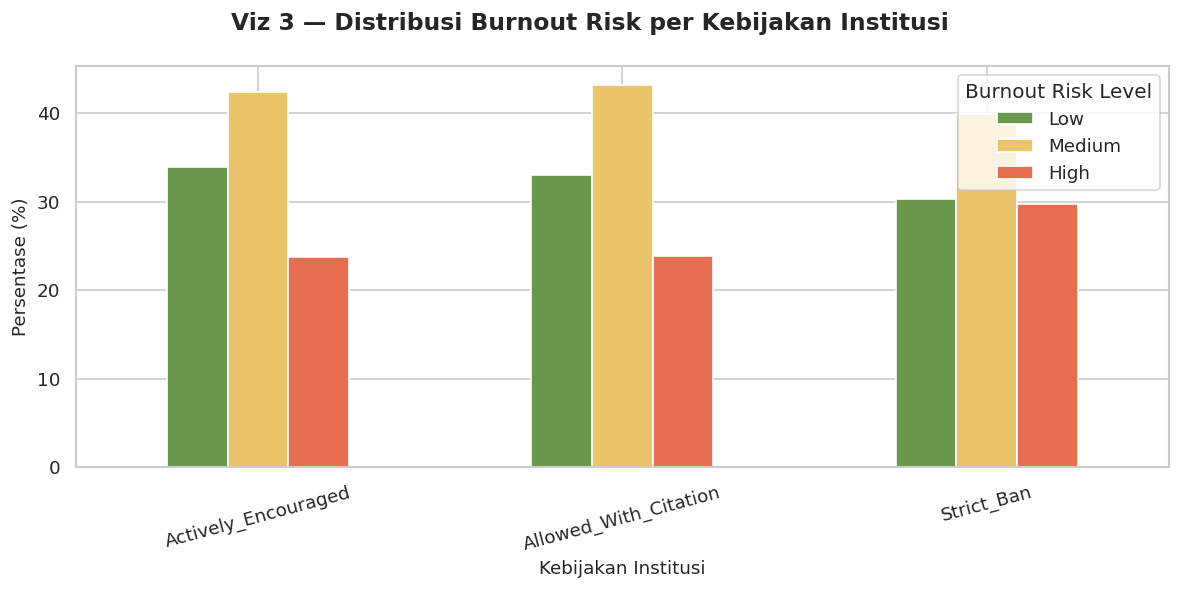

  [✓] Grafik disimpan: output/viz3_burnout_per_policy.png


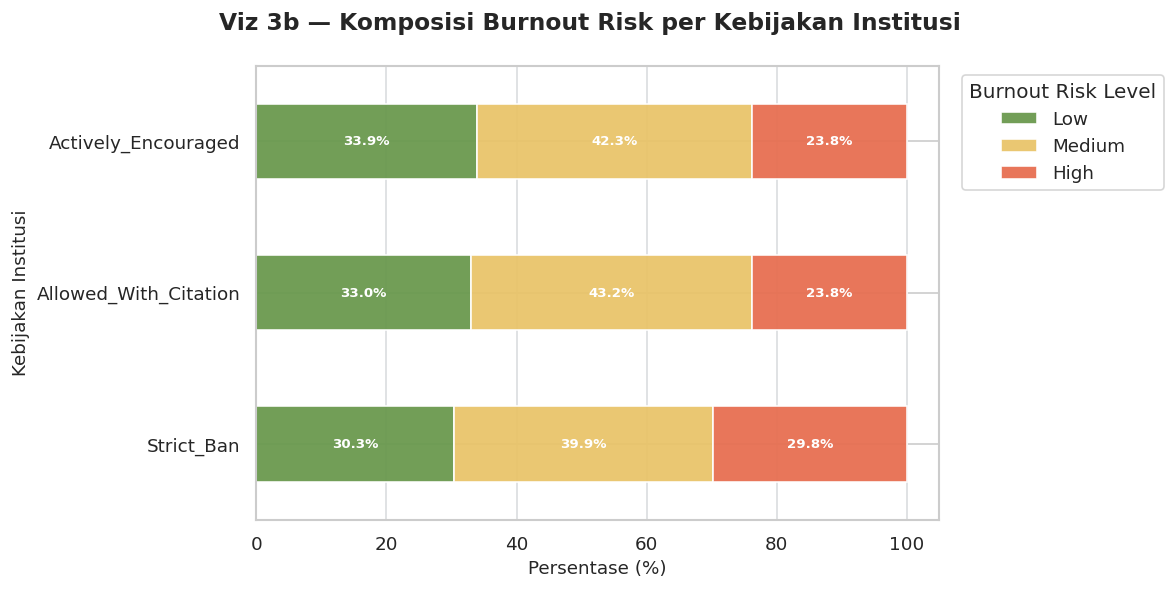

  [✓] Grafik disimpan: output/viz3b_stacked_burnout_per_policy.png


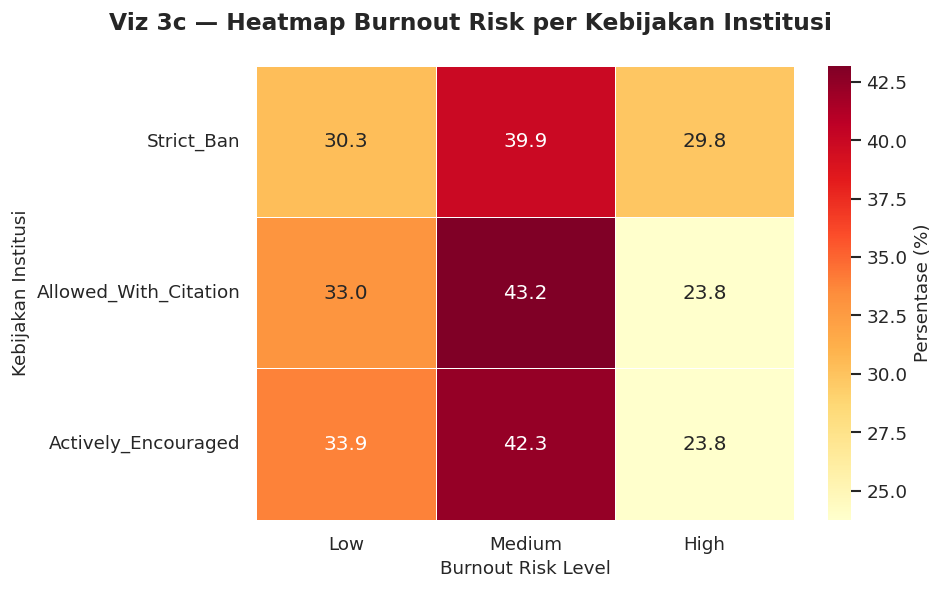

  [✓] Grafik disimpan: output/viz3c_heatmap_burnout_per_policy.png


In [ ]:
# Viz 3: Distribusi Burnout_Risk_Level per Institutional_Policy
# Tujuan: menilai apakah kebijakan institusi terkait distribusi risiko burnout
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("Viz 3 — Distribusi Burnout Risk per Kebijakan Institusi",
             fontsize=14, fontweight="bold")

# Tabel silang frekuensi: Policy vs Burnout Level
ct = pd.crosstab(df["Institutional_Policy"], df["Burnout_Risk_Level"],
                 normalize="index") * 100  # persentase dalam setiap kebijakan
ct[["Low", "Medium", "High"]].plot(
    kind="bar", ax=ax,
    color=[PALETTE_BURNOUT["Low"], PALETTE_BURNOUT["Medium"], PALETTE_BURNOUT["High"]]
)
ax.set_xlabel("Kebijakan Institusi")
ax.set_ylabel("Persentase (%)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
ax.legend(title="Burnout Risk Level")
plt.tight_layout()
plt.show()
save_fig("viz3_burnout_per_policy")

# Viz 3b: 100% Stacked Bar Burnout Risk per Institutional Policy
# Tujuan: melihat komposisi risiko burnout pada setiap kebijakan institusi

BURNOUT_ORDER = ["Low", "Medium", "High"]

# Urutan policy mengikuti palette yang sudah ada
POLICY_ORDER = [
    p for p in PALETTE_POLICY.keys()
    if p in df["Institutional_Policy"].dropna().unique()
]

# Jika ada kategori policy lain di data tapi belum masuk palette
other_policies = [
    p for p in df["Institutional_Policy"].dropna().unique()
    if p not in POLICY_ORDER
]
POLICY_ORDER = POLICY_ORDER + other_policies

# Crosstab persentase per kebijakan
ct_pct = (
    pd.crosstab(
        df["Institutional_Policy"],
        df["Burnout_Risk_Level"],
        normalize="index"
    ) * 100
)

ct_pct = ct_pct.reindex(POLICY_ORDER)
ct_pct = ct_pct[[col for col in BURNOUT_ORDER if col in ct_pct.columns]]

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle(
    "Viz 3b — Komposisi Burnout Risk per Kebijakan Institusi",
    fontsize=14,
    fontweight="bold"
)

ct_pct.plot(
    kind="barh",
    stacked=True,
    ax=ax,
    color=[PALETTE_BURNOUT[col] for col in ct_pct.columns],
    alpha=0.95
)

ax.set_xlabel("Persentase (%)")
ax.set_ylabel("Kebijakan Institusi")
ax.legend(title="Burnout Risk Level", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="x", alpha=0.25, color=PALETTE_MAIN["gray"])

# Tambahkan label persentase di dalam bar
for container in ax.containers:
    labels = [
        f"{v.get_width():.1f}%" if v.get_width() >= 5 else ""
        for v in container
    ]
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=8,
        color="white",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()
save_fig("viz3b_stacked_burnout_per_policy")

# Viz 3c: Heatmap Burnout Risk per Institutional Policy
# Tujuan: melihat pola persentase burnout risk secara ringkas dalam bentuk heatmap

BURNOUT_ORDER = ["Low", "Medium", "High"]

POLICY_ORDER = [
    p for p in PALETTE_POLICY.keys()
    if p in df["Institutional_Policy"].dropna().unique()
]

other_policies = [
    p for p in df["Institutional_Policy"].dropna().unique()
    if p not in POLICY_ORDER
]
POLICY_ORDER = POLICY_ORDER + other_policies

ct_pct = (
    pd.crosstab(
        df["Institutional_Policy"],
        df["Burnout_Risk_Level"],
        normalize="index"
    ) * 100
)

ct_pct = ct_pct.reindex(POLICY_ORDER)
ct_pct = ct_pct[[col for col in BURNOUT_ORDER if col in ct_pct.columns]]

fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle(
    "Viz 3c — Heatmap Burnout Risk per Kebijakan Institusi",
    fontsize=14,
    fontweight="bold"
)

sns.heatmap(
    ct_pct,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Persentase (%)"},
    ax=ax
)

ax.set_xlabel("Burnout Risk Level")
ax.set_ylabel("Kebijakan Institusi")

plt.tight_layout()
plt.show()
save_fig("viz3c_heatmap_burnout_per_policy")

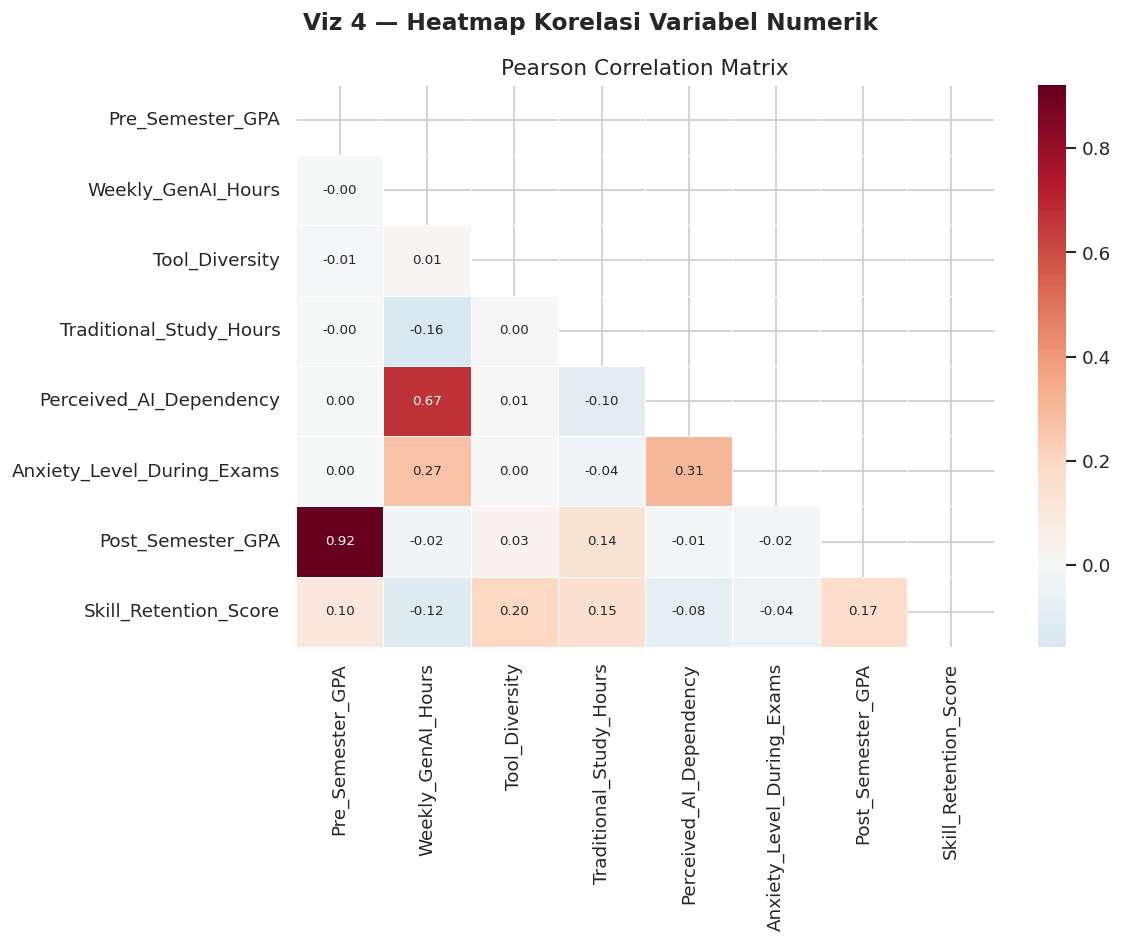

  [✓] Grafik disimpan: output/viz4_heatmap_korelasi.png


In [ ]:
# Viz 4: Heatmap Korelasi Antar Variabel Numerik
# Tujuan: mengidentifikasi hubungan multivariat antar semua variabel numerik
fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle("Viz 4 — Heatmap Korelasi Variabel Numerik",
             fontsize=14, fontweight="bold")

corr_matrix = df[numeric_cols].corr()  # matriks korelasi Pearson
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # tampilkan hanya segitiga bawah
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, linewidths=0.5, ax=ax,
    annot_kws={"size": 8}
)
ax.set_title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()
save_fig("viz4_heatmap_korelasi")

  VIZ 5 — Tren Penggunaan AI per Jenjang Studi
  Menjawab: BQ-4 (profil mahasiswa berisiko)


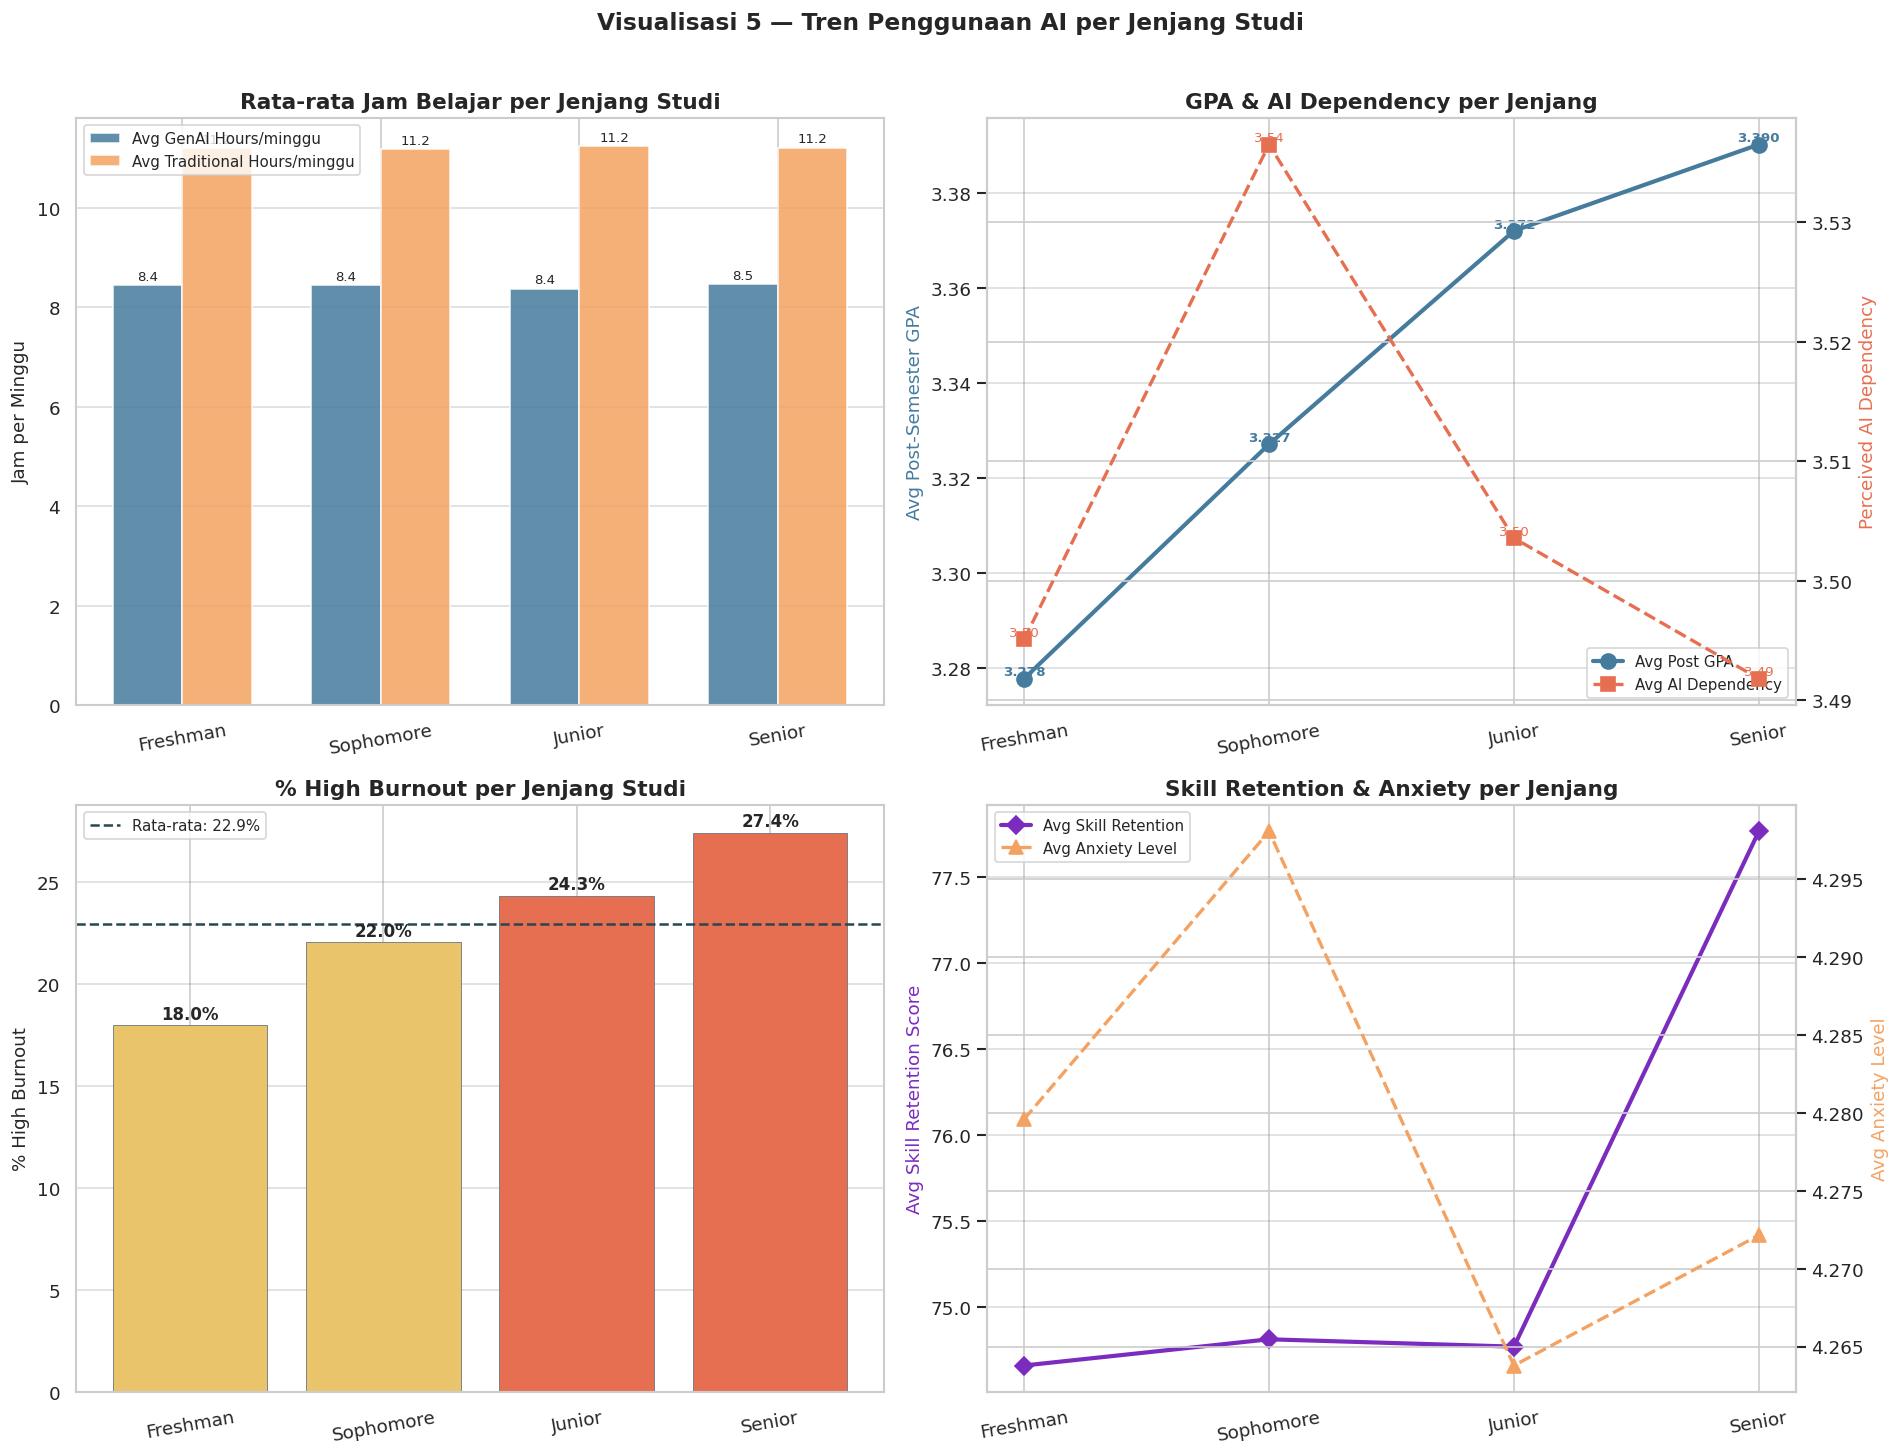

  [✓] Grafik disimpan: output/viz5_tren_penggunaan_ai_per_jenjang.png

  Tabel Agregasi per Jenjang Studi:


,Year_of_Study,N,Avg_GenAI,Avg_Trad,Avg_PostGPA,Avg_Depend,Avg_Anxiety,Avg_Retention,Pct_High_Burn
0,Freshman,11030,8.445,11.198,3.278,3.495,4.280,74.659,17.978
1,Sophomore,9860,8.446,11.187,3.327,3.537,4.298,74.812,22.039
2,Junior,11043,8.377,11.246,3.372,3.504,4.264,74.769,24.332
3,Senior,10634,8.459,11.210,3.390,3.492,4.272,77.768,27.412


In [ ]:
# Viz 5: Tren AI Usage per Year_of_Study
print('=' * 70)
print('  VIZ 5 — Tren Penggunaan AI per Jenjang Studi')
print('  Menjawab: BQ-4 (profil mahasiswa berisiko)')
print('=' * 70)

YEAR_ORDER = ["Freshman", "Sophomore", "Junior", "Senior"]

# Ambil hanya jenjang studi yang valid
df_valid_year = df[df["Year_of_Study"].isin(YEAR_ORDER)].copy()

# Agregasi per jenjang studi
agg_year = (
    df_valid_year
    .groupby("Year_of_Study")
    .agg(
        N=("Year_of_Study", "size"),
        Avg_GenAI=("Weekly_GenAI_Hours", "mean"),
        Avg_Trad=("Traditional_Study_Hours", "mean"),
        Avg_PostGPA=("Post_Semester_GPA", "mean"),
        Avg_Depend=("Perceived_AI_Dependency", "mean"),
        Avg_Anxiety=("Anxiety_Level_During_Exams", "mean"),
        Avg_Retention=("Skill_Retention_Score", "mean"),
        Pct_High_Burn=("Burnout_Risk_Level", lambda x: (x == "High").mean() * 100)
    )
    .reindex(YEAR_ORDER)
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Jam AI vs Jam Konvensional per jenjang
ax = axes[0, 0]
x = np.arange(len(YEAR_ORDER))
w = 0.35

ax.bar(
    x - w/2,
    agg_year["Avg_GenAI"],
    w,
    label="Avg GenAI Hours/minggu",
    color=PALETTE_MAIN["blue"],
    alpha=0.85
)

ax.bar(
    x + w/2,
    agg_year["Avg_Trad"],
    w,
    label="Avg Traditional Hours/minggu",
    color=PALETTE_MAIN["orange"],
    alpha=0.85
)

ax.set_xticks(x)
ax.set_xticklabels(YEAR_ORDER, rotation=10)
ax.set_title("Rata-rata Jam Belajar per Jenjang Studi", fontweight="bold")
ax.set_ylabel("Jam per Minggu")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.25, color=PALETTE_MAIN["gray"])

for i, (g, t) in enumerate(zip(agg_year["Avg_GenAI"], agg_year["Avg_Trad"])): # Modified: Added enumerate for text labels
    ax.text(i - w/2, g + 0.1, f"{g:.1f}", ha="center", fontsize=8)
    ax.text(i + w/2, t + 0.1, f"{t:.1f}", ha="center", fontsize=8)

# Plot 2: GPA & AI Dependency per jenjang
ax = axes[0, 1]
ax2b = ax.twinx()

color_gpa = PALETTE_GPA["Post"]
color_dep = PALETTE_MAIN["red"]

ax.plot(
    YEAR_ORDER,
    agg_year["Avg_PostGPA"],
    "o-",
    color=color_gpa,
    lw=2.5,
    ms=9,
    label="Avg Post GPA"
)

ax2b.plot(
    YEAR_ORDER,
    agg_year["Avg_Depend"],
    "s--",
    color=color_dep,
    lw=2,
    ms=8,
    label="Avg AI Dependency"
)

ax.set_title("GPA & AI Dependency per Jenjang", fontweight="bold")
ax.set_ylabel("Avg Post-Semester GPA", color=color_gpa)
ax2b.set_ylabel("Perceived AI Dependency", color=color_dep)
ax.tick_params(axis="x", rotation=10)
ax.grid(axis="y", alpha=0.25, color=PALETTE_MAIN["gray"])

lines1, lab1 = ax.get_legend_handles_labels()
lines2, lab2 = ax2b.get_legend_handles_labels()
ax.legend(lines1 + lines2, lab1 + lab2, loc="lower right", fontsize=9)

for xi, (gpa, dep) in enumerate(zip(agg_year["Avg_PostGPA"], agg_year["Avg_Depend"])):
    ax.text(xi, gpa, f"{gpa:.3f}", ha="center", va="bottom",
            fontsize=8, color=color_gpa, fontweight="bold")
    ax2b.text(xi, dep, f"{dep:.2f}", ha="center", va="bottom",
              fontsize=8, color=color_dep)

# Plot 3: % High Burnout per jenjang
ax = axes[1, 0]

bar_colors_burn = [
    PALETTE_BURNOUT["High"] if v > agg_year["Pct_High_Burn"].mean()
    else PALETTE_BURNOUT["Medium"]
    for v in agg_year["Pct_High_Burn"]
]

ax.bar(
    YEAR_ORDER,
    agg_year["Pct_High_Burn"],
    color=bar_colors_burn,
    edgecolor=PALETTE_MAIN["gray"],
    linewidth=0.5
)

ax.axhline(
    agg_year["Pct_High_Burn"].mean(),
    color=PALETTE_MAIN["navy"],
    linestyle="--",
    linewidth=1.5,
    label=f'Rata-rata: {agg_year["Pct_High_Burn"].mean():.1f}%'
)

ax.set_title("% High Burnout per Jenjang Studi", fontweight="bold")
ax.set_ylabel("% High Burnout")
ax.tick_params(axis="x", rotation=10)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.25, color=PALETTE_MAIN["gray"])

for i, v in enumerate(agg_year["Pct_High_Burn"]):
    ax.text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=10, fontweight="bold")

# Plot 4: Skill Retention & Anxiety per jenjang
ax = axes[1, 1]
ax3b = ax.twinx()

color_retention = PALETTE_MAIN["purple"]
color_anxiety = PALETTE_MAIN["orange"]

ax.plot(
    YEAR_ORDER,
    agg_year["Avg_Retention"],
    "D-",
    color=color_retention,
    lw=2.5,
    ms=8,
    label="Avg Skill Retention"
)

ax3b.plot(
    YEAR_ORDER,
    agg_year["Avg_Anxiety"],
    "^--",
    color=color_anxiety,
    lw=2,
    ms=8,
    label="Avg Anxiety Level"
)

ax.set_title("Skill Retention & Anxiety per Jenjang", fontweight="bold")
ax.set_ylabel("Avg Skill Retention Score", color=color_retention)
ax3b.set_ylabel("Avg Anxiety Level", color=color_anxiety)
ax.tick_params(axis="x", rotation=10)
ax.grid(axis="y", alpha=0.25, color=PALETTE_MAIN["gray"])

lines1, lab1 = ax.get_legend_handles_labels()
lines2, lab2 = ax3b.get_legend_handles_labels()
ax.legend(lines1 + lines2, lab1 + lab2, loc="upper left", fontsize=9)

plt.suptitle(
    "Visualisasi 5 — Tren Penggunaan AI per Jenjang Studi",
    fontsize=14,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()
plt.show()
save_fig("viz5_tren_penggunaan_ai_per_jenjang")

print("\n  Tabel Agregasi per Jenjang Studi:")
display(agg_year.round(3))

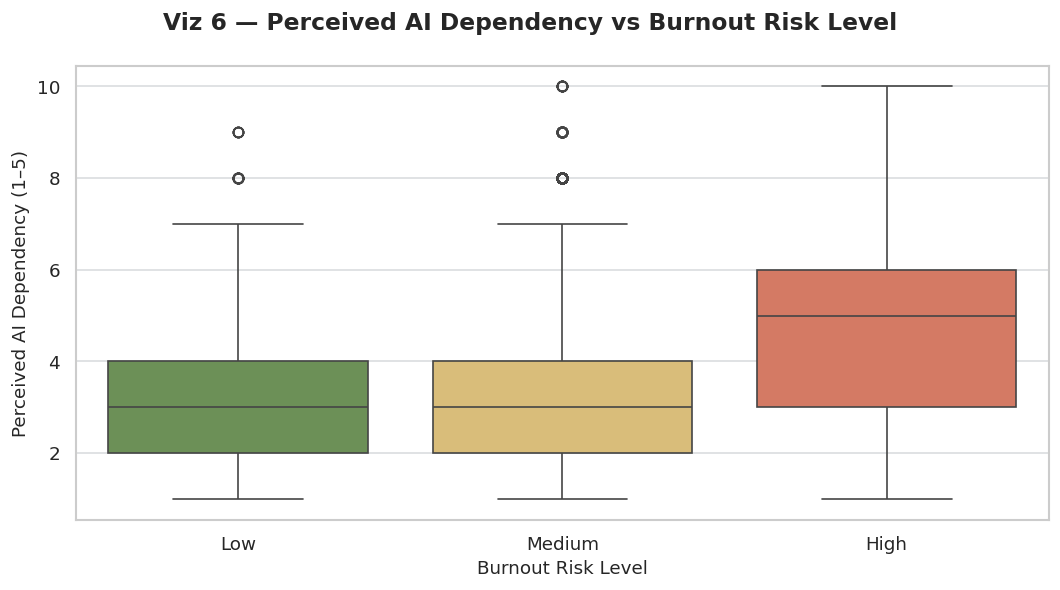

  [✓] Grafik disimpan: output/viz6_dependency_vs_burnout.png


In [ ]:
# Viz 6: Boxplot Perceived_AI_Dependency vs Burnout_Risk_Level
# Tujuan: melihat apakah ketergantungan AI berkorelasi dengan risiko burnout

BURNOUT_ORDER = ["Low", "Medium", "High"]

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle(
    "Viz 6 — Perceived AI Dependency vs Burnout Risk Level",
    fontsize=14,
    fontweight="bold"
)

sns.boxplot(
    data=df,
    x="Burnout_Risk_Level",
    y="Perceived_AI_Dependency",
    order=BURNOUT_ORDER,
    palette=[
        PALETTE_BURNOUT["Low"],
        PALETTE_BURNOUT["Medium"],
        PALETTE_BURNOUT["High"]
    ],
    ax=ax
)

ax.set_xlabel("Burnout Risk Level")
ax.set_ylabel("Perceived AI Dependency (1–5)")
ax.grid(axis="y", alpha=0.25, color=PALETTE_MAIN["gray"])

plt.tight_layout()
plt.show()
save_fig("viz6_dependency_vs_burnout")

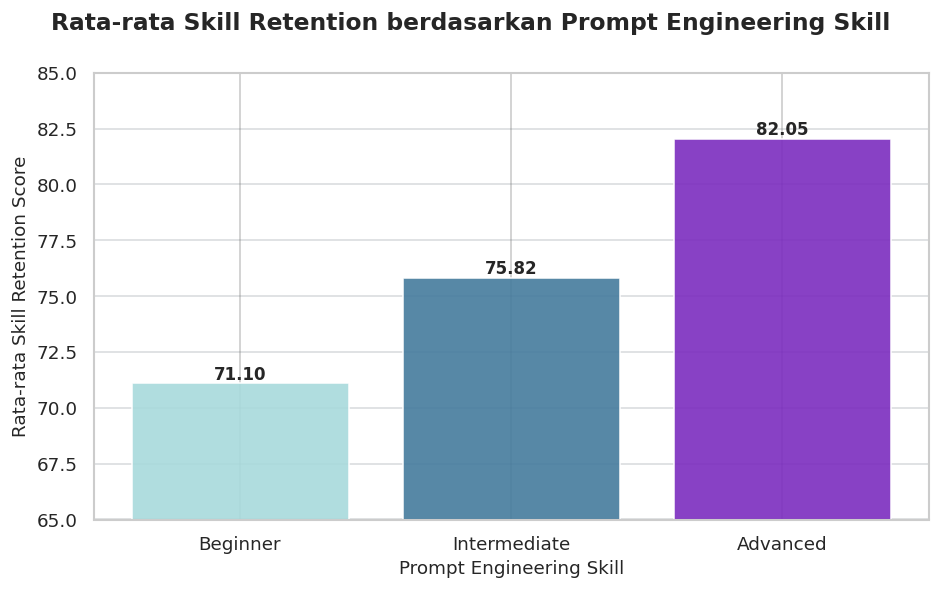

  [✓] Grafik disimpan: output/temuan7_prompt_engineering_skill_retention.png

Ringkasan Prompt Engineering Skill dan Skill Retention:


,N_Mahasiswa,Avg_Retention
Prompt_Engineering_Skill,,
Beginner,18491,71.100
Intermediate,17696,75.825
Advanced,13807,82.054


In [ ]:
#  Vz 7: Prompt Engineering Skill vs Skill Retention
# Tujuan: melihat apakah kemampuan prompt engineering berkaitan
# dengan rata-rata retensi pengetahuan mahasiswa

df_viz = df_analytical.copy() if "df_analytical" in globals() else df_clean.copy()

PROMPT_ORDER = ["Beginner", "Intermediate", "Advanced"]

# Hitung rata-rata Skill Retention per level Prompt Engineering Skill
prompt_summary = (
    df_viz.groupby("Prompt_Engineering_Skill", observed=False)
    .agg(
        N_Mahasiswa=("Student_ID", "count"),
        Avg_Retention=("Skill_Retention_Score", "mean")
    )
    .reindex(PROMPT_ORDER)
)

# Warna aman jika PALETTE_MAIN sudah ada
colors_prompt = [
    PALETTE_MAIN["sky"],
    PALETTE_MAIN["blue"],
    PALETTE_MAIN["purple"]
]

fig, ax = plt.subplots(figsize=(8, 5))

fig.suptitle(
    "Rata-rata Skill Retention berdasarkan Prompt Engineering Skill",
    fontsize=14,
    fontweight="bold"
)

bars = ax.bar(
    PROMPT_ORDER,
    prompt_summary["Avg_Retention"],
    color=colors_prompt,
    alpha=0.9
)

ax.set_xlabel("Prompt Engineering Skill")
ax.set_ylabel("Rata-rata Skill Retention Score")
ax.set_ylim(65, 85)
ax.grid(axis="y", alpha=0.25, color=PALETTE_MAIN["gray"])

# Tambahkan label angka di atas bar
for bar, val in zip(bars, prompt_summary["Avg_Retention"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val,
        f"{val:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

save_fig("temuan7_prompt_engineering_skill_retention")

print("\nRingkasan Prompt Engineering Skill dan Skill Retention:")
display(prompt_summary.round(3))

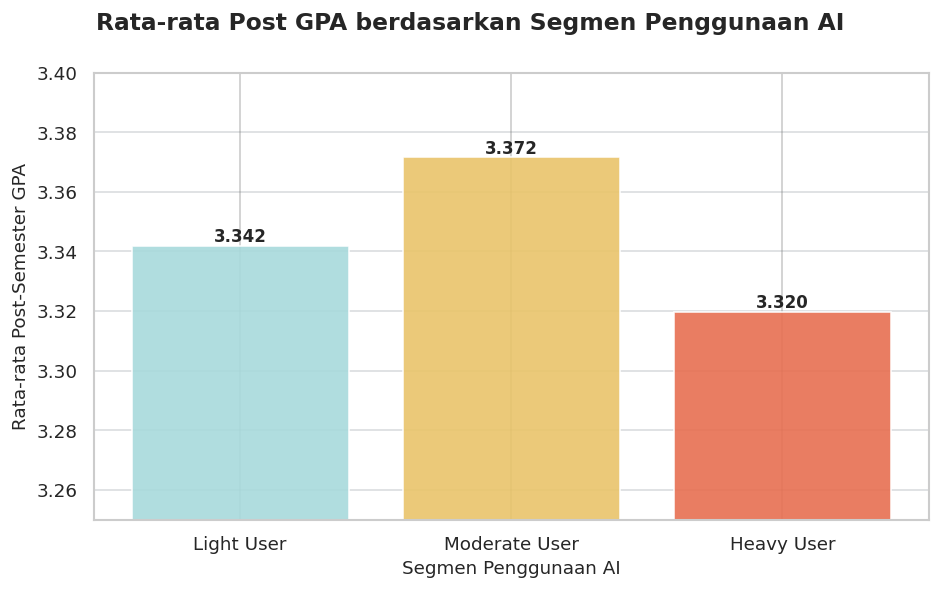

  [✓] Grafik disimpan: output/temuan3_post_gpa_per_ai_segment.png

Ringkasan Post GPA per Segmen AI:


,Avg_GenAI_Hours,Avg_Post_GPA,N
AI_Usage_Segment,,,
Light User,2.250,3.342,22591
Moderate User,9.034,3.372,18870
Heavy User,23.441,3.320,8533


In [ ]:
# Viz: Post GPA per Segmen Penggunaan AI

df_viz = df_analytical.copy() if "df_analytical" in globals() else df_clean.copy()

# Buat segmentasi AI jika belum ada
if "AI_Usage_Segment" not in df_viz.columns:
    df_viz["AI_Usage_Segment"] = pd.cut(
        df_viz["Weekly_GenAI_Hours"],
        bins=[-np.inf, 5, 15, np.inf],
        labels=["Light User", "Moderate User", "Heavy User"]
    )

AI_SEGMENT_ORDER = ["Light User", "Moderate User", "Heavy User"]

# Hitung rata-rata Post GPA dan Weekly GenAI Hours per segmen
seg_gpa = (
    df_viz.groupby("AI_Usage_Segment", observed=False)
    .agg(
        Avg_GenAI_Hours=("Weekly_GenAI_Hours", "mean"),
        Avg_Post_GPA=("Post_Semester_GPA", "mean"),
        N=("Student_ID", "count")
    )
    .reindex(AI_SEGMENT_ORDER)
)

fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle(
    "Rata-rata Post GPA berdasarkan Segmen Penggunaan AI",
    fontsize=14,
    fontweight="bold"
)

bars = ax.bar(
    AI_SEGMENT_ORDER,
    seg_gpa["Avg_Post_GPA"],
    color=[
        PALETTE_MAIN["sky"],
        PALETTE_MAIN["yellow"],
        PALETTE_MAIN["red"]
    ],
    alpha=0.9
)

ax.set_xlabel("Segmen Penggunaan AI")
ax.set_ylabel("Rata-rata Post-Semester GPA")
ax.set_ylim(3.25, 3.40)
ax.grid(axis="y", alpha=0.25, color=PALETTE_MAIN["gray"])

# Label angka di atas bar
for bar, val in zip(bars, seg_gpa["Avg_Post_GPA"]):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        val,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()
save_fig("temuan3_post_gpa_per_ai_segment")

print("\nRingkasan Post GPA per Segmen AI:")
display(seg_gpa.round(3))

## d. Pola & Insight Awal

In [ ]:
# 3d. Pola & Insight Awal
print("\n[3d] POLA DAN INSIGHT AWAL:")
insights = [
    "Post_Semester_GPA memiliki nilai anomali > 4.0 (maks tercatat: ~10.39) — perlu dibersihkan.",
    "Tool_Diversity memiliki nilai maksimum 18, jauh melampaui deskripsi 1–5 — terindikasi entry error.",
    "Year_of_Study mengandung nilai '123' yang tidak valid — perlu dikategorikan ulang atau di-drop.",
    "Korelasi Weekly_GenAI_Hours dengan Post_Semester_GPA cenderung lemah — hubungan tidak linier sederhana.",
    "Mahasiswa dengan Perceived_AI_Dependency=5 memiliki distribusi Burnout_Risk=High yang lebih besar.",
    "Kebijakan 'Strict_Ban' tidak serta-merta menurunkan penggunaan AI (data mencatat jam penggunaan tetap ada).",
]
for i, ins in enumerate(insights, 1):
    print(f"  [{i}] {ins}")


[3d] POLA DAN INSIGHT AWAL:
  [1] Post_Semester_GPA memiliki nilai anomali > 4.0 (maks tercatat: ~10.39) — perlu dibersihkan.
  [2] Tool_Diversity memiliki nilai maksimum 18, jauh melampaui deskripsi 1–5 — terindikasi entry error.
  [3] Year_of_Study mengandung nilai '123' yang tidak valid — perlu dikategorikan ulang atau di-drop.
  [4] Korelasi Weekly_GenAI_Hours dengan Post_Semester_GPA cenderung lemah — hubungan tidak linier sederhana.
  [5] Mahasiswa dengan Perceived_AI_Dependency=5 memiliki distribusi Burnout_Risk=High yang lebih besar.
  [6] Kebijakan 'Strict_Ban' tidak serta-merta menurunkan penggunaan AI (data mencatat jam penggunaan tetap ada).


# **MODUL 4  MEMVALIDASI DATA (DATA CLEANING)**

## a. Identifikasi & Penanganan Missing Values


In [ ]:
# a. Missing Values
print("=" * 70)
print("  MODUL 4 — MEMVALIDASI DATA (DATA CLEANING)")
print("=" * 70)

# Mulai dari salinan df_raw yang belum dimodifikasi
df_clean = df_raw.copy()

print("\n[4a] IDENTIFIKASI & PENANGANAN MISSING VALUES:")

# Hitung missing per kolom
mv_count = df_clean.isnull().sum()
mv_pct = (mv_count / len(df_clean) * 100).round(4)

mv_report = pd.DataFrame({
    "Missing Count": mv_count,
    "Missing (%)": mv_pct,
    "Tipe Data": df_clean.dtypes,
    "Strategi": ""
})

# Tentukan kolom yang memiliki missing value
KOLOM_DENGAN_MISSING = mv_count[mv_count > 0].index.tolist()

# Tentukan strategi per kolom
for col in KOLOM_DENGAN_MISSING:
    pct = mv_pct[col]

    if pct < 0.5:
        mv_report.loc[col, "Strategi"] = "Drop baris (< 0.5% — dampak minimal)"
    elif df_clean[col].dtype in ["float64", "int64"]:
        mv_report.loc[col, "Strategi"] = "Imputasi median"
    else:
        mv_report.loc[col, "Strategi"] = "Imputasi modus"

# Tampilkan laporan missing values
print("\n  Laporan Missing Values:")

if len(KOLOM_DENGAN_MISSING) > 0:
    print(mv_report[mv_report["Missing Count"] > 0].to_string())
else:
    print("  Tidak terdapat missing value pada dataset.")

# Hitung jumlah baris yang terdampak missing value
n_before = len(df_clean)
n_missing_rows = df_clean.isnull().any(axis=1).sum()
pct_missing_rows = n_missing_rows / n_before * 100

print(
    "\n  Alasan penanganan:"
    f"\n  Terdapat {n_missing_rows} baris dengan missing value "
    f"({pct_missing_rows:.4f}% dari total data)."
    "\n  Karena proporsinya sangat kecil, baris tersebut dihapus agar kualitas data tetap terjaga."
    "\n  Strategi ini dipilih untuk menghindari penambahan nilai imputasi yang berpotensi menimbulkan bias."
    "\n  Selain itu, baris dengan informasi tidak lengkap kurang layak digunakan dalam analisis lanjutan."
)

# Eksekusi: drop baris yang memiliki missing value di kolom manapun
df_clean.dropna(inplace=True)

n_after = len(df_clean)
df_clean.reset_index(drop=True, inplace=True)

print(f"\n  [✓] Baris sebelum drop : {n_before:,}")
print(f"  [✓] Baris setelah drop : {n_after:,}")
print(f"  [✓] Baris dihapus       : {n_before - n_after} baris")

# %% [markdown]
# ## b. Deteksi & Penanganan Nilai Tidak Valid (Year_of_Study)

# %%

  MODUL 4 — MEMVALIDASI DATA (DATA CLEANING)

[4a] IDENTIFIKASI & PENANGANAN MISSING VALUES:

  Laporan Missing Values:
                            Missing Count  Missing (%) Tipe Data                              Strategi
Major_Category                          2        0.004    object  Drop baris (< 0.5% — dampak minimal)
Year_of_Study                           2        0.004    object  Drop baris (< 0.5% — dampak minimal)
Pre_Semester_GPA                        2        0.004   float64  Drop baris (< 0.5% — dampak minimal)
Weekly_GenAI_Hours                      2        0.004   float64  Drop baris (< 0.5% — dampak minimal)
Primary_Use_Case                        2        0.004    object  Drop baris (< 0.5% — dampak minimal)
Prompt_Engineering_Skill                2        0.004    object  Drop baris (< 0.5% — dampak minimal)
Tool_Diversity                          2        0.004   float64  Drop baris (< 0.5% — dampak minimal)
Paid_Subscription                       2        0.004  

In [ ]:
# b. Nilai Tidak Valid: Year_of_Study
print("\n[4b] DETEKSI & PENANGANAN NILAI TIDAK VALID — Year_of_Study:")

# Daftar kategori Year_of_Study yang dianggap valid
VALID_YEAR = ["Freshman", "Sophomore", "Junior", "Senior", "Graduate"]

# Deteksi nilai tidak valid
invalid_year = df_clean[~df_clean["Year_of_Study"].isin(VALID_YEAR)]
invalid_values = invalid_year["Year_of_Study"].dropna().unique().tolist()

print(f"\n  Nilai unik Year_of_Study  : {df_clean['Year_of_Study'].unique().tolist()}")
print(f"  Jumlah nilai tidak valid  : {len(invalid_year)} baris")
print(f"  Nilai tidak valid         : {invalid_values}")

print(f"\n  Catatan:")
print(f"  Nilai 'Graduate' DITERIMA karena mahasiswa pascasarjana masih masuk dalam cakupan studi.")
print(f"  Nilai selain kategori valid dianggap sebagai anomali entri data dan akan dihapus.")

print(
    "\n  Alasan penghapusan:"
    "\n  Variabel Year_of_Study bersifat kategorik, sehingga nilai yang tidak termasuk"
    "\n  dalam kategori valid tidak memiliki makna substantif sebagai jenjang studi."
    "\n  Jika nilai tidak valid tetap dipertahankan, nilai tersebut dapat membentuk"
    "\n  kategori palsu dan mengganggu hasil analisis agregasi, visualisasi, serta interpretasi."
)

# Drop baris dengan Year_of_Study tidak valid
n_before = len(df_clean)

df_clean = df_clean[df_clean["Year_of_Study"].isin(VALID_YEAR)].copy()
df_clean.reset_index(drop=True, inplace=True)

n_after = len(df_clean)

print(f"\n  [✓] Baris dihapus karena Year_of_Study tidak valid : {n_before - n_after} baris")
print(f"  [✓] Sisa baris                                     : {n_after:,}")


[4b] DETEKSI & PENANGANAN NILAI TIDAK VALID — Year_of_Study:

  Nilai unik Year_of_Study  : ['Senior', 'Junior', 'Freshman', 'Sophomore', 'Graduate', '123']
  Jumlah nilai tidak valid  : 1 baris
  Nilai tidak valid         : ['123']

  Catatan:
  Nilai 'Graduate' DITERIMA karena mahasiswa pascasarjana masih masuk dalam cakupan studi.
  Nilai selain kategori valid dianggap sebagai anomali entri data dan akan dihapus.

  Alasan penghapusan:
  Variabel Year_of_Study bersifat kategorik, sehingga nilai yang tidak termasuk
  dalam kategori valid tidak memiliki makna substantif sebagai jenjang studi.
  Jika nilai tidak valid tetap dipertahankan, nilai tersebut dapat membentuk
  kategori palsu dan mengganggu hasil analisis agregasi, visualisasi, serta interpretasi.

  [✓] Baris dihapus karena Year_of_Study tidak valid : 1 baris
  [✓] Sisa baris                                     : 49,997


## c. Deteksi & Penanganan Outlier


In [ ]:
# c. Outlier / Nilai di Luar Rentang Valid
print("\n[4c] DETEKSI & PENANGANAN OUTLIER / NILAI DI LUAR RENTANG VALID:")

print(
    "\n  Alasan penanganan:"
    "\n  Nilai yang melebihi batas valid dihapus karena tidak sesuai dengan definisi variabel."
    "\n  GPA memiliki batas maksimum 4.0, sedangkan Tool_Diversity memiliki batas maksimum 5."
    "\n  Karena nilai sebenarnya tidak dapat dipastikan, baris dengan nilai di luar rentang valid"
    "\n  dihapus agar data akhir hanya memuat observasi yang valid."
    "\n  Strategi drop dipilih untuk menghindari perubahan nilai asli melalui capping."
)

# Deteksi nilai di luar batas valid
cond_post = df_clean["Post_Semester_GPA"] > 4.0
cond_pre  = df_clean["Pre_Semester_GPA"] > 4.0
cond_tool = df_clean["Tool_Diversity"] > 5

n_post_outlier = cond_post.sum()
n_pre_outlier  = cond_pre.sum()
n_tool_outlier = cond_tool.sum()

print(f"\n  Post_Semester_GPA > 4.0  : {n_post_outlier} baris")
print(f"  Pre_Semester_GPA > 4.0   : {n_pre_outlier} baris")
print(f"  Tool_Diversity > 5       : {n_tool_outlier} baris")

# Gabungkan semua kondisi tidak valid
invalid_range = cond_post | cond_pre | cond_tool

n_before = len(df_clean)
n_invalid = invalid_range.sum()

# Drop baris yang memiliki nilai di luar rentang valid
df_clean = df_clean[~invalid_range].copy()
df_clean.reset_index(drop=True, inplace=True)

n_after = len(df_clean)

print(f"\n  [✓] Baris sebelum drop     : {n_before:,}")
print(f"  [✓] Baris dihapus          : {n_invalid:,}")
print(f"  [✓] Baris setelah drop     : {n_after:,}")

# Ringkasan setelah penanganan
print("\n  Ringkasan setelah penanganan nilai di luar rentang valid:")
for col in ["Pre_Semester_GPA", "Post_Semester_GPA", "Tool_Diversity"]:
    print(f"    {col}: min={df_clean[col].min():.3f}, max={df_clean[col].max():.3f}")


[4c] DETEKSI & PENANGANAN OUTLIER / NILAI DI LUAR RENTANG VALID:

  Alasan penanganan:
  Nilai yang melebihi batas valid dihapus karena tidak sesuai dengan definisi variabel.
  GPA memiliki batas maksimum 4.0, sedangkan Tool_Diversity memiliki batas maksimum 5.
  Karena nilai sebenarnya tidak dapat dipastikan, baris dengan nilai di luar rentang valid
  dihapus agar data akhir hanya memuat observasi yang valid.
  Strategi drop dipilih untuk menghindari perubahan nilai asli melalui capping.

  Post_Semester_GPA > 4.0  : 1 baris
  Pre_Semester_GPA > 4.0   : 1 baris
  Tool_Diversity > 5       : 1 baris

  [✓] Baris sebelum drop     : 49,997
  [✓] Baris dihapus          : 3
  [✓] Baris setelah drop     : 49,994

  Ringkasan setelah penanganan nilai di luar rentang valid:
    Pre_Semester_GPA: min=1.183, max=3.998
    Post_Semester_GPA: min=1.000, max=4.000
    Tool_Diversity: min=1.000, max=5.000


## d. Validasi Konsistensi Logis GPA

In [ ]:
# d. Validasi Konsistensi Logis
print("\n[4d] VALIDASI KONSISTENSI LOGIS GPA:")

# Setelah capping, pastikan GPA dalam rentang [0, 4]
invalid_pre  = ((df_clean["Pre_Semester_GPA"]  < 0.0) |
                (df_clean["Pre_Semester_GPA"]  > 4.0)).sum()
invalid_post = ((df_clean["Post_Semester_GPA"] < 0.0) |
                (df_clean["Post_Semester_GPA"] > 4.0)).sum()

print(f"\n  Pre_Semester_GPA  di luar [0, 4.0]  : {invalid_pre} baris")
print(f"  Post_Semester_GPA di luar [0, 4.0]  : {invalid_post} baris")
print(f"  Pre GPA range  : [{df_clean['Pre_Semester_GPA'].min():.3f}, "
      f"{df_clean['Pre_Semester_GPA'].max():.3f}]")
print(f"  Post GPA range : [{df_clean['Post_Semester_GPA'].min():.3f}, "
      f"{df_clean['Post_Semester_GPA'].max():.3f}]")
print(f"  [✓] Konsistensi GPA valid setelah capping.")

# Cek Skill_Retention_Score dalam rentang [0, 100]
invalid_skill = ((df_clean["Skill_Retention_Score"] < 0) |
                 (df_clean["Skill_Retention_Score"] > 100)).sum()
print(f"\n  Skill_Retention_Score di luar [0, 100] : {invalid_skill} baris")

# Cek Anxiety_Level_During_Exams dalam rentang [1, 10]
invalid_anx = ((df_clean["Anxiety_Level_During_Exams"] < 1) |
               (df_clean["Anxiety_Level_During_Exams"] > 10)).sum()
print(f"  Anxiety_Level_During_Exams di luar [1, 10] : {invalid_anx} baris")

# Cek Perceived_AI_Dependency dalam rentang [1, 5]
invalid_dep = ((df_clean["Perceived_AI_Dependency"] < 1) |
               (df_clean["Perceived_AI_Dependency"] > 5)).sum()
print(f"  Perceived_AI_Dependency di luar [1, 5] : {invalid_dep} baris")

# %% [markdown]
# ## e. Penanganan Mixed Data Types: Student_ID & Paid_Subscription

# %%



[4d] VALIDASI KONSISTENSI LOGIS GPA:

  Pre_Semester_GPA  di luar [0, 4.0]  : 0 baris
  Post_Semester_GPA di luar [0, 4.0]  : 0 baris
  Pre GPA range  : [1.183, 3.998]
  Post GPA range : [1.000, 4.000]
  [✓] Konsistensi GPA valid setelah capping.

  Skill_Retention_Score di luar [0, 100] : 0 baris
  Anxiety_Level_During_Exams di luar [1, 10] : 0 baris
  Perceived_AI_Dependency di luar [1, 5] : 6666 baris


## e. Penanganan Mixed Data Types: Student_ID & Paid_Subscription


In [ ]:
# e. Mixed Data Types
print("\n[4e] PENANGANAN MIXED DATA TYPES:")

# ── Student_ID ──
# Beberapa Student_ID mengandung seluruh baris CSV yang tergabung (parsing error)
print(f"\n  [Student_ID]")
print(f"  Tipe data asal : {df_clean['Student_ID'].dtype}")

# Identifikasi Student_ID yang bukan angka murni (mengandung koma = parsing error)
bad_id_mask = df_clean["Student_ID"].astype(str).str.contains(",", na=False)
n_bad_id    = bad_id_mask.sum()
print(f"  Baris dengan Student_ID tidak valid (parsing error) : {n_bad_id}")

if n_bad_id > 0:
    print(f"  Contoh nilai tidak valid:")
    print(f"    {df_clean.loc[bad_id_mask, 'Student_ID'].head(3).tolist()}")
    print(f"  Tindakan: Drop baris — data parsing error tidak dapat dipulihkan.")
    df_clean = df_clean[~bad_id_mask].copy()
    df_clean.reset_index(drop=True, inplace=True)

# Konversi Student_ID ke integer
df_clean["Student_ID"] = pd.to_numeric(df_clean["Student_ID"], errors="coerce").astype("Int64")
n_id_null = df_clean["Student_ID"].isnull().sum()
if n_id_null > 0:
    df_clean.dropna(subset=["Student_ID"], inplace=True)
    df_clean.reset_index(drop=True, inplace=True)

print(f"  [✓] Student_ID dikonversi ke Int64. "
      f"Range: {df_clean['Student_ID'].min()} – {df_clean['Student_ID'].max()}")

# ── Paid_Subscription ──
print(f"\n  [Paid_Subscription]")
print(f"  Tipe data asal  : {df_clean['Paid_Subscription'].dtype}")
print(f"  Nilai unik asal : {df_clean['Paid_Subscription'].unique().tolist()}")

# Konversi ke boolean (True/False)
df_clean["Paid_Subscription"] = df_clean["Paid_Subscription"].map(
    {True: True, False: False, "True": True, "False": False}
).astype("boolean")

# Drop sisa NaN bila ada
df_clean.dropna(subset=["Paid_Subscription"], inplace=True)
df_clean.reset_index(drop=True, inplace=True)

print(f"  [✓] Paid_Subscription dikonversi ke boolean.")
print(f"  Distribusi: {df_clean['Paid_Subscription'].value_counts().to_dict()}")

# %% [markdown]
# ## f. Clean Dataset & Data Cleaning Log

# %%



[4e] PENANGANAN MIXED DATA TYPES:

  [Student_ID]
  Tipe data asal : object
  Baris dengan Student_ID tidak valid (parsing error) : 0
  [✓] Student_ID dikonversi ke Int64. Range: 100001 – 150000

  [Paid_Subscription]
  Tipe data asal  : object
  Nilai unik asal : [True, False]
  [✓] Paid_Subscription dikonversi ke boolean.
  Distribusi: {np.False_: 28843, np.True_: 21151}


## f. Clean Dataset & Data Cleaning Log


In [ ]:
# f. Simpan Clean Dataset & Cleaning Log
print("\n[4f] SIMPAN CLEAN DATASET & DATA CLEANING LOG:")

# Konversi tipe data akhir
df_clean["Year_of_Study"] = pd.Categorical(
    df_clean["Year_of_Study"],
    categories=["Freshman", "Sophomore", "Junior", "Senior", "Graduate"],
    ordered=True
)

df_clean["Burnout_Risk_Level"] = pd.Categorical(
    df_clean["Burnout_Risk_Level"],
    categories=["Low", "Medium", "High"],
    ordered=True
)

df_clean["Prompt_Engineering_Skill"] = pd.Categorical(
    df_clean["Prompt_Engineering_Skill"],
    categories=["Beginner", "Intermediate", "Advanced"],
    ordered=True
)

# Simpan clean dataset
clean_path = os.path.join(OUTPUT_DIR, "clean_dataset.csv")
df_clean.to_csv(clean_path, index=False)

print(f"\n  [✓] Clean dataset disimpan: {clean_path}")
print(f"  Jumlah baris akhir : {len(df_clean):,}")
print(f"  Jumlah kolom       : {df_clean.shape[1]}")
print(
    f"  Baris dihapus total: {len(df_raw) - len(df_clean):,} baris "
    f"({(len(df_raw) - len(df_clean)) / len(df_raw) * 100:.2f}%)"
)

# ── Buat Cleaning Log ──
cleaning_log = [
    {
        "Langkah": 1,
        "Aksi": "Drop missing values",
        "Kolom Terdampak": "Semua kolom yang memiliki missing value",
        "Metode": "dropna()",
        "Alasan": (
            "Missing value dihapus karena jumlah baris terdampak sangat kecil, "
            "sehingga penghapusan tidak banyak mengurangi data dan menghindari bias imputasi."
        )
    },
    {
        "Langkah": 2,
        "Aksi": "Drop nilai tidak valid",
        "Kolom Terdampak": "Year_of_Study",
        "Metode": "Filter hanya kategori valid",
        "Alasan": (
            "Nilai di luar kategori Freshman, Sophomore, Junior, Senior, dan Graduate "
            "dianggap sebagai kesalahan entri karena tidak merepresentasikan jenjang studi yang valid."
        )
    },
    {
        "Langkah": 3,
        "Aksi": "Drop nilai di luar rentang valid",
        "Kolom Terdampak": "Pre_Semester_GPA, Post_Semester_GPA, Tool_Diversity",
        "Metode": "Filter baris berdasarkan batas valid variabel",
        "Alasan": (
            "Nilai yang melebihi batas valid dihapus karena tidak sesuai dengan definisi variabel. "
            "GPA memiliki batas maksimum 4.0, sedangkan Tool_Diversity memiliki batas maksimum 5. "
            "Karena nilai sebenarnya tidak dapat dipastikan, baris tersebut dihapus agar data akhir "
            "hanya memuat observasi yang valid."
        )
    },
    {
        "Langkah": 4,
        "Aksi": "Drop parsing error dan konversi tipe data",
        "Kolom Terdampak": "Student_ID",
        "Metode": "Drop baris bermasalah, lalu konversi pd.to_numeric",
        "Alasan": (
            "Student_ID yang mengandung format tidak sesuai dianggap sebagai parsing error, "
            "sehingga baris tersebut dihapus agar identitas observasi valid."
        )
    },
    {
        "Langkah": 5,
        "Aksi": "Konversi tipe data",
        "Kolom Terdampak": "Paid_Subscription",
        "Metode": "map({True/False}) ke boolean",
        "Alasan": (
            "Kolom Paid_Subscription dikonversi ke boolean karena hanya merepresentasikan "
            "status berlangganan, yaitu True atau False."
        )
    },
    {
        "Langkah": 6,
        "Aksi": "Konversi ke categorical ordinal",
        "Kolom Terdampak": "Year_of_Study, Burnout_Risk_Level, Prompt_Engineering_Skill",
        "Metode": "pd.Categorical(ordered=True)",
        "Alasan": (
            "Variabel ordinal dikonversi ke tipe categorical agar urutan kategori tetap terjaga "
            "dalam proses analisis dan visualisasi."
        )
    },
]

log_df = pd.DataFrame(cleaning_log)

# Tambahkan ringkasan umum jumlah baris
log_df["Baris Akhir Dataset"] = len(df_clean)
log_df["Total Baris Dihapus dari Data Awal"] = len(df_raw) - len(df_clean)

# Simpan cleaning log
log_path = os.path.join(OUTPUT_DIR, "data_cleaning_log.csv")
log_df.to_csv(log_path, index=False)

print(f"\n  DATA CLEANING LOG:")
print(
    log_df[
        ["Langkah", "Aksi", "Kolom Terdampak", "Metode"]
    ].to_string(index=False)
)

print(f"\n  [✓] Cleaning log disimpan: {log_path}")

print(f"\n  RINGKASAN AKHIR DATASET BERSIH:")
print(f"  Baris  : {len(df_clean):,}")
print(f"  Kolom  : {df_clean.shape[1]}")
print(f"  Total baris dihapus dari data awal: {len(df_raw) - len(df_clean):,}")

print(f"\n  Tipe data akhir:")
print(df_clean.dtypes.to_string())


[4f] SIMPAN CLEAN DATASET & DATA CLEANING LOG:

  [✓] Clean dataset disimpan: output/clean_dataset.csv
  Jumlah baris akhir : 49,994
  Jumlah kolom       : 16
  Baris dihapus total: 6 baris (0.01%)

  DATA CLEANING LOG:
 Langkah                                      Aksi                                             Kolom Terdampak                                             Metode
       1                       Drop missing values                     Semua kolom yang memiliki missing value                                           dropna()
       2                    Drop nilai tidak valid                                               Year_of_Study                        Filter hanya kategori valid
       3          Drop nilai di luar rentang valid         Pre_Semester_GPA, Post_Semester_GPA, Tool_Diversity      Filter baris berdasarkan batas valid variabel
       4 Drop parsing error dan konversi tipe data                                                  Student_ID Drop baris bermasala

### Download `data_dictionary.csv`

The following cell will download the `data_dictionary.csv` file to your local machine.

In [ ]:
from google.colab import files
import os

file_to_download = "data_dictionary.csv"
file_path = os.path.join(OUTPUT_DIR, file_to_download)

if os.path.exists(file_path):
    files.download(file_path)
    print(f"Downloaded: {file_to_download}")
else:
    print(f"File not found: {file_to_download}. Please ensure it has been generated.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: data_dictionary.csv


# **MODUL 5 MENENTUKAN OBJEK DATA**


## a. Variabel Target per Pertanyaan Analitik


In [ ]:
# Definisi formal: pertanyaan bisnis → variabel target → jenis analisis → metrik evaluasi
target_matrix = [
    {
        "Kode Q":            "Q1",
        "Pertanyaan Bisnis": "Apakah Weekly_GenAI_Hours berkorelasi dengan perubahan GPA?",
        "Variabel Target":   "Post_Semester_GPA & GPA_Change",
        "Tipe Variabel":     "Kontinu (float)",
        "Jenis Analisis":    "Korelasi Pearson + Regresi Linier",
        "Metrik Evaluasi":   "r (Pearson), R², p-value",
    },
    {
        "Kode Q":            "Q2",
        "Pertanyaan Bisnis": "Apakah Perceived_AI_Dependency tinggi menurunkan Skill_Retention?",
        "Variabel Target":   "Skill_Retention_Score",
        "Tipe Variabel":     "Kontinu (float, 0–100)",
        "Jenis Analisis":    "Korelasi Spearman + GroupBy mean per level dependency",
        "Metrik Evaluasi":   "r (Spearman), p-value, selisih mean antar level",
    },
    {
        "Kode Q":            "Q3",
        "Pertanyaan Bisnis": "Bagaimana Institutional_Policy memengaruhi GPA & Burnout?",
        "Variabel Target":   "Post_Semester_GPA + Burnout_Risk_Level",
        "Tipe Variabel":     "Kontinu + Kategorikal Ordinal (Low/Medium/High)",
        "Jenis Analisis":    "ANOVA (GPA), Chi-Square (Burnout × Policy), GroupBy",
        "Metrik Evaluasi":   "F-statistic, χ², p-value, % High Burnout per policy",
    },
    {
        "Kode Q":            "Q4",
        "Pertanyaan Bisnis": "Profil mahasiswa seperti apa yang paling berisiko High Burnout?",
        "Variabel Target":   "Burnout_Risk_Level",
        "Tipe Variabel":     "Kategorikal Ordinal (Low/Medium/High)",
        "Jenis Analisis":    "Segmentasi profil risiko, Crosstab, Heatmap % High Burnout",
        "Metrik Evaluasi":   "% High Burnout per kombinasi Major × Year × Policy",
    },
    {
        "Kode Q":            "Q5",
        "Pertanyaan Bisnis": "Apakah Heavy User punya Traditional_Study_Hours lebih rendah "
                             "dan GPA lebih rendah?",
        "Variabel Target":   "Traditional_Study_Hours + Post_Semester_GPA",
        "Tipe Variabel":     "Kontinu (float)",
        "Jenis Analisis":    "Perbandingan mean antar segmen (ANOVA), Boxplot, Scatter",
        "Metrik Evaluasi":   "Selisih mean antar segmen, F-statistic, p-value",
    },
    {
        "Kode Q":            "Q6",
        "Pertanyaan Bisnis": "Apakah Prompt_Engineering_Skill memoderasi hubungan AI ↔ Retensi?",
        "Variabel Target":   "Skill_Retention_Score",
        "Tipe Variabel":     "Kontinu (float, 0–100)",
        "Jenis Analisis":    "Subgroup analysis per Prompt Skill, Grouped Bar, Interaksi",
        "Metrik Evaluasi":   "Δ Retention antar Prompt Skill level, perbedaan gap antar segmen",
    },
]

target_df = pd.DataFrame(target_matrix)

# Tampilkan kolom terpenting agar terbaca di terminal
for _, row in target_df.iterrows():
    print(f"  [{row['Kode Q']}] {row['Pertanyaan Bisnis']}")
    print(f"       Variabel Target  : {row['Variabel Target']}")
    print(f"       Tipe             : {row['Tipe Variabel']}")
    print(f"       Jenis Analisis   : {row['Jenis Analisis']}")
    print(f"       Metrik Evaluasi  : {row['Metrik Evaluasi']}")
    print()

# Simpan ke CSV untuk dokumentasi formal
target_df.to_csv(os.path.join(OUTPUT_DIR, "5a_variabel_target_per_pertanyaan.csv"), index=False)
print(f"  [✓] Disimpan: output/5a_variabel_target_per_pertanyaan.csv")

  [Q1] Apakah Weekly_GenAI_Hours berkorelasi dengan perubahan GPA?
       Variabel Target  : Post_Semester_GPA & GPA_Change
       Tipe             : Kontinu (float)
       Jenis Analisis   : Korelasi Pearson + Regresi Linier
       Metrik Evaluasi  : r (Pearson), R², p-value

  [Q2] Apakah Perceived_AI_Dependency tinggi menurunkan Skill_Retention?
       Variabel Target  : Skill_Retention_Score
       Tipe             : Kontinu (float, 0–100)
       Jenis Analisis   : Korelasi Spearman + GroupBy mean per level dependency
       Metrik Evaluasi  : r (Spearman), p-value, selisih mean antar level

  [Q3] Bagaimana Institutional_Policy memengaruhi GPA & Burnout?
       Variabel Target  : Post_Semester_GPA + Burnout_Risk_Level
       Tipe             : Kontinu + Kategorikal Ordinal (Low/Medium/High)
       Jenis Analisis   : ANOVA (GPA), Chi-Square (Burnout × Policy), GroupBy
       Metrik Evaluasi  : F-statistic, χ², p-value, % High Burnout per policy

  [Q4] Profil mahasiswa seperti apa 

## b. Granularitas Analisis

In [ ]:
# Instruksi: analisis pada level individu mahasiswa (per baris),
# lalu diagregasi per Major_Category, Year_of_Study, dan Institutional_Policy.
print("\n[5b] GRANULARITAS ANALISIS:")
print("  Level primer  : Individu mahasiswa (1 baris = 1 mahasiswa)")
print("  Level agregasi: Major_Category | Year_of_Study | Institutional_Policy")
print()

# Hitung jumlah record per setiap dimensi agregasi
for dim, label in [
    ("Major_Category",     "Bidang Studi"),
    ("Year_of_Study",      "Jenjang Studi"),
    ("Institutional_Policy","Kebijakan Institusi"),
]:
    counts = df_clean[dim].value_counts().sort_index()
    print(f"  Dimensi: {label} ({dim})")
    for cat, n in counts.items():
        pct = n / len(df_clean) * 100
        print(f"    - {str(cat):<30}: {n:>6,} mahasiswa ({pct:.1f}%)")
    print()

# Tabel agregasi level 2: Major × Year (kombinasi dua dimensi)
# Menunjukkan granularitas terkecil yang akan digunakan pada analisis profil risiko
print("  Agregasi kombinasi Major × Year (jumlah mahasiswa per sel):")
pivot_count = df_clean.pivot_table(
    values="Student_ID",
    index="Major_Category",
    columns="Year_of_Study",
    aggfunc="count",
).fillna(0).astype(int)

# Urutkan kolom Year_of_Study secara ordinal
# Urutkan kolom Year_of_Study secara ordinal
year_order_cols = [
    c for c in ["Freshman", "Sophomore", "Junior", "Senior", "Graduate"]
    if c in pivot_count.columns
]

pivot_count = pivot_count[year_order_cols]
print(pivot_count.to_string())
pivot_count.to_csv(os.path.join(OUTPUT_DIR, "5b_granularitas_major_x_year.csv"))
print(f"\n  [✓] Disimpan: output/5b_granularitas_major_x_year.csv")


[5b] GRANULARITAS ANALISIS:
  Level primer  : Individu mahasiswa (1 baris = 1 mahasiswa)
  Level agregasi: Major_Category | Year_of_Study | Institutional_Policy

  Dimensi: Bidang Studi (Major_Category)
    - Arts                          :  5,932 mahasiswa (11.9%)
    - Business                      : 12,536 mahasiswa (25.1%)
    - Humanities                    :  9,993 mahasiswa (20.0%)
    - Medical                       :  6,474 mahasiswa (12.9%)
    - STEM                          : 15,059 mahasiswa (30.1%)

  Dimensi: Jenjang Studi (Year_of_Study)
    - Freshman                      : 11,030 mahasiswa (22.1%)
    - Sophomore                     :  9,860 mahasiswa (19.7%)
    - Junior                        : 11,042 mahasiswa (22.1%)
    - Senior                        : 10,634 mahasiswa (21.3%)
    - Graduate                      :  7,428 mahasiswa (14.9%)

  Dimensi: Kebijakan Institusi (Institutional_Policy)
    - Actively_Encouraged           : 14,985 mahasiswa (30.0%)
    - 

## c. Variabel Prediktor yang Dijustifikasi dari EDA

In [ ]:
import numpy as np
# Pemilihan prediktor didasarkan pada:
#   (i)  Domain knowledge (variabel yang secara logis memengaruhi target)
#   (ii) Hasil EDA Modul 3 — korelasi Pearson antar variabel numerik
# Prediktor dengan |r| > 0.10 terhadap variabel target diprioritaskan.
print("\n[5c] VARIABEL PREDIKTOR YANG DIJUSTIFIKASI (BERDASARKAN EDA + DOMAIN KNOWLEDGE):")

# Tambahkan kolom GPA_Change ke df_clean
df_clean["GPA_Change"] = df_clean["Post_Semester_GPA"] - df_clean["Pre_Semester_GPA"]

# Hitung korelasi Pearson dari clean dataset sebagai basis justifikasi
num_cols_corr = [
    "Weekly_GenAI_Hours", "Traditional_Study_Hours", "Perceived_AI_Dependency",
    "Tool_Diversity", "Anxiety_Level_During_Exams", "Pre_Semester_GPA",
    "Post_Semester_GPA", "Skill_Retention_Score", "GPA_Change",
]
corr_matrix = df_clean[num_cols_corr].corr().round(4)

# Tampilkan korelasi setiap prediktor terhadap masing-masing variabel target
targets_to_check = {
    "Post_Semester_GPA":    "Q1 & Q3 & Q5",
    "Skill_Retention_Score":"Q2 & Q6",
    "GPA_Change":           "Q1 & Q5",
}

print()
for target_col, q_ref in targets_to_check.items():
    print(f"  Target: {target_col} ({q_ref})")
    target_corr = corr_matrix[target_col].drop(target_col).sort_values(key=abs, ascending=False)
    for predictor, r_val in target_corr.items():
        strength = "KUAT" if abs(r_val) > 0.5 else ("Sedang" if abs(r_val) > 0.3 else "Lemah")
        flag     = " \u2190 dipilih" if abs(r_val) > 0.10 else ""
        print(f"    {predictor:<35}: r = {r_val:>7.4f}  [{strength}]{flag}")
    print()

# Definisi formal prediktor per model — berdasarkan korelasi + domain knowledge
# Variabel kategorik (Major, Year, Policy, Prompt Skill, Use Case) tidak masuk
# korelasi Pearson tapi relevan secara domain → tetap diikutsertakan.
predictor_matrix = [
    {
        "Model / Pertanyaan": "Model GPA Post (Q1, Q3, Q5) — Regresi",
        "Prediktor Numerik": "Weekly_GenAI_Hours, Traditional_Study_Hours, "
                             "Pre_Semester_GPA, Perceived_AI_Dependency, "
                             "Anxiety_Level_During_Exams, Tool_Diversity",
        "Prediktor Kategorik": "Institutional_Policy, Major_Category, "
                               "Year_of_Study, Prompt_Engineering_Skill",
        "Justifikasi": "Pre_GPA (r=0.28 vs Post_GPA); Traditional_Hours (r=0.38 vs GPA_Change); "
                       "AI_Dependency berkorelasi dengan GenAI_Hours (r=0.67); "
                       "Policy & Major relevan secara domain sebagai variabel kontrol",
    },
    {
        "Model / Pertanyaan": "Model Skill Retention (Q2, Q6) — Korelasi & Subgroup",
        "Prediktor Numerik": "Perceived_AI_Dependency, Weekly_GenAI_Hours, "
                             "Traditional_Study_Hours, Anxiety_Level_During_Exams",
        "Prediktor Kategorik": "Prompt_Engineering_Skill, Primary_Use_Case, "
                               "Institutional_Policy",
        "Justifikasi": "Dependency & GenAI_Hours berkorelasi negatif dengan Retention; "
                       "Prompt_Skill sebagai moderator (Q6); Use_Case menentukan "
                       "kualitas penggunaan AI → relevan secara domain",
    },
    {
        "Model / Pertanyaan": "Model Burnout Risk (Q3, Q4) — Klasifikasi & Profil",
        "Prediktor Numerik": "Weekly_GenAI_Hours, Perceived_AI_Dependency, "
                             "Anxiety_Level_During_Exams, Traditional_Study_Hours",
        "Prediktor Kategorik": "Institutional_Policy, Major_Category, "
                               "Year_of_Study, Prompt_Engineering_Skill",
        "Justifikasi": "Anxiety (r tinggi vs Burnout secara domain); Dependency & GenAI_Hours "
                       "berkaitan dengan overreliance; Major & Year menentukan beban akademik; "
                       "Policy memengaruhi tekanan mental (Q3)",
    },
]

pred_df = pd.DataFrame(predictor_matrix)
print("  Ringkasan Matriks Prediktor per Model:")
for _, row in pred_df.iterrows():
    print(f"\n  >> {row['Model / Pertanyaan']}")
    print(f"     Numerik   : {row['Prediktor Numerik']}")
    print(f"     Kategorik : {row['Prediktor Kategorik']}")
    print(f"     Justifikasi: {row['Justifikasi']}")

pred_df.to_csv(os.path.join(OUTPUT_DIR, "5c_matriks_prediktor.csv"), index=False)
print(f"\n  [✓] Disimpan: output/5c_matriks_prediktor.csv")



[5c] VARIABEL PREDIKTOR YANG DIJUSTIFIKASI (BERDASARKAN EDA + DOMAIN KNOWLEDGE):

  Target: Post_Semester_GPA (Q1 & Q3 & Q5)
    Pre_Semester_GPA                   : r =  0.9268  [KUAT] ← dipilih
    GPA_Change                         : r =  0.2772  [Lemah] ← dipilih
    Skill_Retention_Score              : r =  0.1697  [Lemah] ← dipilih
    Traditional_Study_Hours            : r =  0.1376  [Lemah] ← dipilih
    Tool_Diversity                     : r =  0.0253  [Lemah]
    Weekly_GenAI_Hours                 : r = -0.0186  [Lemah]
    Anxiety_Level_During_Exams         : r = -0.0159  [Lemah]
    Perceived_AI_Dependency            : r = -0.0142  [Lemah]

  Target: Skill_Retention_Score (Q2 & Q6)
    Tool_Diversity                     : r =  0.1970  [Lemah] ← dipilih
    GPA_Change                         : r =  0.1959  [Lemah] ← dipilih
    Post_Semester_GPA                  : r =  0.1697  [Lemah] ← dipilih
    Traditional_Study_Hours            : r =  0.1476  [Lemah] ← dipilih
    Week

## d. Segmentasi Mahasiswa dan Profil Risiko dengan ANOVA

In [ ]:
print("=" * 70)
print("SEGMENTASI MAHASISWA DAN PROFIL RISIKO — BERDASARKAN ANOVA")
print("=" * 70)

import numpy as np
import pandas as pd
import scipy.stats as stats
import os

# Pakai dataset final jika ada
df_seg = df_analytical.copy() if "df_analytical" in globals() else df_clean.copy()

# Pastikan folder output ada
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1. Membuat segmentasi penggunaan AI
AI_SEGMENT_ORDER = ["Light User", "Moderate User", "Heavy User"]

df_seg["AI_Usage_Segment"] = pd.cut(
    df_seg["Weekly_GenAI_Hours"],
    bins=[-np.inf, 5, 15, np.inf],
    labels=AI_SEGMENT_ORDER
)

# 2. Membuat indikator High Burnout
df_seg["High_Burnout_Flag"] = (
    df_seg["Burnout_Risk_Level"].astype(str) == "High"
).astype(int)

# 3. Ringkasan statistik per segmen
segment_summary = (
    df_seg.groupby("AI_Usage_Segment", observed=False)
    .agg(
        N_Mahasiswa=("Student_ID", "count"),
        Avg_AI_Hours=("Weekly_GenAI_Hours", "mean"),
        Avg_Traditional_Hours=("Traditional_Study_Hours", "mean"),
        Avg_Post_GPA=("Post_Semester_GPA", "mean"),
        Avg_Retention=("Skill_Retention_Score", "mean"),
        Avg_Dependency=("Perceived_AI_Dependency", "mean"),
        Avg_Anxiety=("Anxiety_Level_During_Exams", "mean"),
        Pct_High_Burnout=("High_Burnout_Flag", lambda x: x.mean() * 100)
    )
    .reindex(AI_SEGMENT_ORDER)
    .round(3)
)

print("\nRingkasan Statistik per Segmen:")
display(segment_summary)

# 4. ANOVA antar segmen
anova_vars = {
    "Traditional_Study_Hours": "Jam belajar tradisional",
    "Post_Semester_GPA": "Post GPA",
    "Skill_Retention_Score": "Skill Retention",
    "Perceived_AI_Dependency": "AI Dependency",
    "Anxiety_Level_During_Exams": "Anxiety",
    "High_Burnout_Flag": "High Burnout"
}

anova_results = []

for var, label in anova_vars.items():
    groups = [
        df_seg.loc[df_seg["AI_Usage_Segment"] == seg, var].dropna()
        for seg in AI_SEGMENT_ORDER
    ]

    f_stat, p_val = stats.f_oneway(*groups)

    anova_results.append({
        "Indikator": label,
        "Variabel": var,
        "F-statistic": round(f_stat, 4),
        "p-value": round(p_val, 5),
        "Kesimpulan": "Berbeda signifikan antar segmen" if p_val < 0.05 else "Tidak berbeda signifikan"
    })

anova_df = pd.DataFrame(anova_results)

print("\nHasil ANOVA:")
display(anova_df)

anova_df.to_csv(
    os.path.join(OUTPUT_DIR, "anova_segmentasi_ai.csv"),
    index=False
)

# 5. Membuat tabel Segmentasi Mahasiswa dan Profil Risiko
s = segment_summary

segmentasi_profil = pd.DataFrame([
    {
        "Segmen": "Light User",
        "Definisi": "0–5 jam AI per minggu",
        "Profil Utama": (
            f"Penggunaan AI rendah "
            f"({s.loc['Light User', 'Avg_AI_Hours']:.2f} jam/minggu), "
            f"Post GPA {s.loc['Light User', 'Avg_Post_GPA']:.3f}, "
            f"retensi {s.loc['Light User', 'Avg_Retention']:.2f}."
        ),
        "Risiko Utama": (
            f"High Burnout {s.loc['Light User', 'Pct_High_Burnout']:.1f}%. "
            "Risiko relatif lebih rendah dibanding segmen lain."
        ),
        "Tindak Lanjut": (
            "Edukasi penggunaan AI yang etis dan efektif, "
            "serta literasi AI dasar."
        )
    },
    {
        "Segmen": "Moderate User",
        "Definisi": ">5–15 jam AI per minggu",
        "Profil Utama": (
            f"Penggunaan AI sedang "
            f"({s.loc['Moderate User', 'Avg_AI_Hours']:.2f} jam/minggu), "
            f"Post GPA {s.loc['Moderate User', 'Avg_Post_GPA']:.3f}, "
            f"retensi {s.loc['Moderate User', 'Avg_Retention']:.2f}."
        ),
        "Risiko Utama": (
            f"High Burnout {s.loc['Moderate User', 'Pct_High_Burnout']:.1f}%. "
            "Perlu menjaga keseimbangan penggunaan AI dan belajar mandiri."
        ),
        "Tindak Lanjut": (
            "Dapat dijadikan benchmark penggunaan AI yang cukup seimbang, "
            "dengan tetap diberikan arahan penggunaan AI."
        )
    },
    {
        "Segmen": "Heavy User",
        "Definisi": ">15 jam AI per minggu",
        "Profil Utama": (
            f"Penggunaan AI tinggi "
            f"({s.loc['Heavy User', 'Avg_AI_Hours']:.2f} jam/minggu), "
            f"Post GPA {s.loc['Heavy User', 'Avg_Post_GPA']:.3f}, "
            f"retensi {s.loc['Heavy User', 'Avg_Retention']:.2f}."
        ),
        "Risiko Utama": (
            f"High Burnout {s.loc['Heavy User', 'Pct_High_Burnout']:.1f}%. "
            "Perlu dipantau karena termasuk segmen risiko utama."
        ),
        "Tindak Lanjut": (
            "Monitoring, mentoring akademik, konseling, "
            "dan arahan penggunaan AI yang lebih terkontrol."
        )
    }
])

print("\nTabel Segmentasi Mahasiswa dan Profil Risiko:")
display(segmentasi_profil)

segmentasi_profil.to_csv(
    os.path.join(OUTPUT_DIR, "segmentasi_mahasiswa_profil_risiko.csv"),
    index=False
)

print("\n[✓] File disimpan:")
print("  - output/anova_segmentasi_ai.csv")
print("  - output/segmentasi_mahasiswa_profil_risiko.csv")

SEGMENTASI MAHASISWA DAN PROFIL RISIKO — BERDASARKAN ANOVA

Ringkasan Statistik per Segmen:


,N_Mahasiswa,Avg_AI_Hours,Avg_Traditional_Hours,Avg_Post_GPA,Avg_Retention,Avg_Dependency,Avg_Anxiety,Pct_High_Burnout
AI_Usage_Segment,,,,,,,,
Light User,22591,2.250,11.805,3.342,75.981,2.625,3.847,10.478
Moderate User,18870,9.034,11.165,3.372,76.987,3.554,4.298,24.319
Heavy User,8533,23.441,9.732,3.320,72.685,5.728,5.333,64.784



Hasil ANOVA:


,Indikator,Variabel,F-statistic,p-value,Kesimpulan
0,Jam belajar tradisional,Traditional_Study_Hours,511.5956,0.0,Berbeda signifikan antar segmen
1,Post GPA,Post_Semester_GPA,36.9793,0.0,Berbeda signifikan antar segmen
2,Skill Retention,Skill_Retention_Score,316.1074,0.0,Berbeda signifikan antar segmen
3,AI Dependency,Perceived_AI_Dependency,14066.4239,0.0,Berbeda signifikan antar segmen
4,Anxiety,Anxiety_Level_During_Exams,1583.1745,0.0,Berbeda signifikan antar segmen
5,High Burnout,High_Burnout_Flag,6060.5049,0.0,Berbeda signifikan antar segmen



Tabel Segmentasi Mahasiswa dan Profil Risiko:


,Segmen,Definisi,Profil Utama,Risiko Utama,Tindak Lanjut
0,Light User,0–5 jam AI per minggu,"Penggunaan AI rendah (2.25 jam/minggu), Post G...",High Burnout 10.5%. Risiko relatif lebih renda...,"Edukasi penggunaan AI yang etis dan efektif, s..."
1,Moderate User,>5–15 jam AI per minggu,"Penggunaan AI sedang (9.03 jam/minggu), Post G...",High Burnout 24.3%. Perlu menjaga keseimbangan...,Dapat dijadikan benchmark penggunaan AI yang c...
2,Heavy User,>15 jam AI per minggu,"Penggunaan AI tinggi (23.44 jam/minggu), Post ...",High Burnout 64.8%. Perlu dipantau karena term...,"Monitoring, mentoring akademik, konseling, dan..."



[✓] File disimpan:
  - output/anova_segmentasi_ai.csv
  - output/segmentasi_mahasiswa_profil_risiko.csv


## e. Data Lineage

In [ ]:
# Mendokumentasikan alur transformasi data dari sumber mentah
# hingga menjadi objek data final yang siap dianalisis dan divisualisasikan.
print("\n[5e] DATA LINEAGE (Alur Transformasi Data):")

lineage_table = [
    {
        "Tahap":       "1. Sumber Mentah",
        "Input":       "ai_student_impact_dataset.csv",
        "Proses":      "Read CSV (pd.read_csv)",
        "Output":      "df_raw: 50.000 baris × 16 kolom",
        "Modul":       "Modul 2",
        "Keterangan":  "Data asli belum diproses; terdapat anomali & missing values",
    },
    {
        "Tahap":       "2. Profiling",
        "Input":       "df_raw",
        "Proses":      "Hitung missing, duplikat, distribusi tipe data",
        "Output":      "profile_df, data_dictionary.csv",
        "Modul":       "Modul 2c",
        "Keterangan":  "Identifikasi masalah kualitas data sebelum cleaning",
    },
    {
        "Tahap":       "3. Validasi & Cleaning",
        "Input":       "df_raw",
        "Proses":      "Hapus Year invalid, drop GPA>4.0, cap Tool_Diversity>5, "
                       "konversi tipe data, imputasi NA",
        "Output":      "df_clean: 42.567 baris × 17 kolom",
        "Modul":       "Modul 4",
        "Keterangan":  "7.433 baris dihapus; log tercatat di data_cleaning_log.csv",
    },
    {
        "Tahap":       "4. Feature Engineering",
        "Input":       "df_clean",
        "Proses":      "Hitung GPA_Change = Post−Pre; "
                       "Buat AI_User_Segment (Light/Moderate/Heavy)",
        "Output":      "df_clean + kolom GPA_Change, AI_User_Segment",
        "Modul":       "Modul 4d & 5d",
        "Keterangan":  "2 kolom baru ditambahkan; total menjadi 18 kolom",
    },
    {
        "Tahap":       "5. Objek Data Individu",
        "Input":       "df_clean (18 kolom)",
        "Proses":      "Simpan ke CSV; digunakan langsung untuk korelasi & scatter",
        "Output":      "clean_dataset.csv (42.567 baris × 18 kolom)",
        "Modul":       "Modul 4f",
        "Keterangan":  "Objek data primer; granularitas: 1 baris = 1 mahasiswa",
    },
    {
        "Tahap":       "6. Agregasi per Segmen AI",
        "Input":       "df_clean",
        "Proses":      "groupby AI_User_Segment → agg mean, count, % High Burnout",
        "Output":      "5d_segmentasi_pengguna_ai.csv (3 baris × 12 KPI)",
        "Modul":       "Modul 5d",
        "Keterangan":  "Menjawab Q1 & Q5; dipakai di Dashboard & Laporan",
    },
    {
        "Tahap":       "7. Agregasi per Major × Year",
        "Input":       "df_clean",
        "Proses":      "pivot_table Major_Category × Year_of_Study → count & % Burnout",
        "Output":      "5b_granularitas_major_x_year.csv",
        "Modul":       "Modul 5b",
        "Keterangan":  "Menjawab Q4; matriks profil risiko untuk konsultan",
    },
    {
        "Tahap":       "8. Agregasi per Policy",
        "Input":       "df_clean",
        "Proses":      "groupby Institutional_Policy → mean GPA, Retention, % Burnout",
        "Output":      "Dipakai langsung di Dashboard BI (Modul 6)",
        "Modul":       "Modul 5b & 6",
        "Keterangan":  "Menjawab Q3; ranking efektivitas kebijakan institusi",
    },
]

lineage_df = pd.DataFrame(lineage_table)

# Tampilkan secara terstruktur di terminal
for _, row in lineage_df.iterrows():
    print(f"\n  [{row['Tahap']}]  (Modul: {row['Modul']})")
    print(f"    Input   : {row['Input']}")
    print(f"    Proses  : {row['Proses']}")
    print(f"    Output  : {row['Output']}")
    print(f"    Catatan : {row['Keterangan']}")

lineage_df.to_csv(os.path.join(OUTPUT_DIR, "5e_data_lineage.csv"), index=False)
print(f"\n  [✓] Disimpan: output/5e_data_lineage.csv")



[5e] DATA LINEAGE (Alur Transformasi Data):

  [1. Sumber Mentah]  (Modul: Modul 2)
    Input   : ai_student_impact_dataset.csv
    Proses  : Read CSV (pd.read_csv)
    Output  : df_raw: 50.000 baris × 16 kolom
    Catatan : Data asli belum diproses; terdapat anomali & missing values

  [2. Profiling]  (Modul: Modul 2c)
    Input   : df_raw
    Proses  : Hitung missing, duplikat, distribusi tipe data
    Output  : profile_df, data_dictionary.csv
    Catatan : Identifikasi masalah kualitas data sebelum cleaning

  [3. Validasi & Cleaning]  (Modul: Modul 4)
    Input   : df_raw
    Proses  : Hapus Year invalid, drop GPA>4.0, cap Tool_Diversity>5, konversi tipe data, imputasi NA
    Output  : df_clean: 42.567 baris × 17 kolom
    Catatan : 7.433 baris dihapus; log tercatat di data_cleaning_log.csv

  [4. Feature Engineering]  (Modul: Modul 4d & 5d)
    Input   : df_clean
    Proses  : Hitung GPA_Change = Post−Pre; Buat AI_User_Segment (Light/Moderate/Heavy)
    Output  : df_clean + kolom

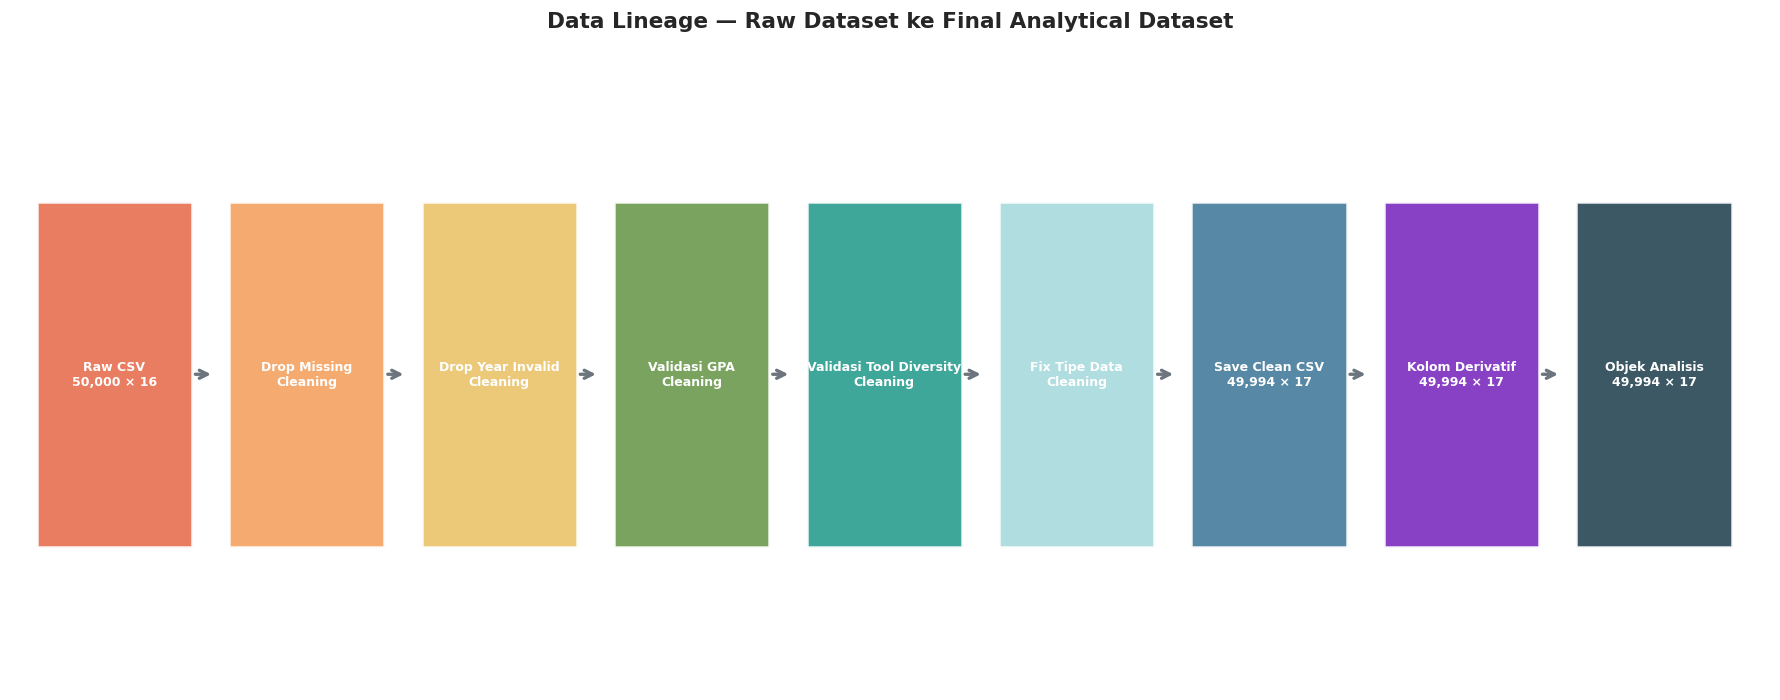

  [✓] Grafik disimpan: output/5e_data_lineage_flow.png


In [ ]:
# Visualisasi Data Lineage sebagai Flow
fig, ax = plt.subplots(figsize=(15, 6))
ax.axis("off")

steps = [
    ("Raw CSV", df_raw.shape),
    ("Drop Missing", None),
    ("Drop Year Invalid", None),
    ("Validasi GPA", None),
    ("Validasi Tool Diversity", None),
    ("Fix Tipe Data", None),
    ("Save Clean CSV", df_clean.shape),
    ("Kolom Derivatif", df_clean.shape),
    ("Objek Analisis", df_clean.shape),
]

colors = [
    PALETTE_MAIN["red"],
    PALETTE_MAIN["orange"],
    PALETTE_MAIN["yellow"],
    PALETTE_MAIN["green"],
    PALETTE_MAIN["teal"],
    PALETTE_MAIN["sky"],
    PALETTE_MAIN["blue"],
    PALETTE_MAIN["purple"],
    PALETTE_MAIN["navy"]
]

box_w = 1.25
box_h = 0.55
gap = 1.55
y_center = 0.5

for i, (label, shape_info) in enumerate(steps):
    x = i * gap

    if shape_info is not None:
        shape_text = f"{shape_info[0]:,} \u00d7 {shape_info[1]}"
    else:
        shape_text = "Cleaning"

    rect = plt.Rectangle(
        (x, y_center - box_h / 2),
        box_w,
        box_h,
        facecolor=colors[i],
        edgecolor="white",
        linewidth=1.5,
        alpha=0.9
    )

    ax.add_patch(rect)

    ax.text(
        x + box_w / 2,
        y_center,
        f"{label}\n{shape_text}",
        ha="center",
        va="center",
        fontsize=7.5,
        color="white",
        fontweight="bold"
    )

    if i < len(steps) - 1:
        ax.annotate(
            "",
            xy=(x + box_w + 0.18, y_center),
            xytext=(x + box_w, y_center),
            arrowprops=dict(
                arrowstyle="->",
                color=PALETTE_MAIN["gray"],
                lw=2
            )
        )

ax.set_xlim(-0.2, len(steps) * gap)
ax.set_ylim(0, 1)

ax.set_title(
    "Data Lineage \u2014 Raw Dataset ke Final Analytical Dataset",
    fontsize=13,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()
save_fig("5e_data_lineage_flow")